In [516]:
import kagglehub
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import re
import html
import pandas as pd
from collections import Counter
import warnings
import matplotlib

# Steam Games Dataset - data analysis and hit prediction

## Overview

Jakiś tekst

## Dataset download

In [576]:
path = kagglehub.dataset_download("fronkongames/steam-games-dataset")
print(f'Dataset saved as {shutil.copy(f"{path}/games.csv", "./games.csv")}')

Dataset saved as ./games.csv


## Data exploration

In [577]:
df = pd.read_csv('games.csv')
pd.set_option('display.max_columns', None)

In [578]:
pd.set_option('display.max_colwidth', 50)
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,NaN,0,252,3,NaN,0,231,NaN,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",[],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,NaN,0,21,3,NaN,0,0,NaN,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],['Korean'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,yujingamesc@gmail.com,True,False,False,0,NaN,0,0,0,NaN,19,0,The game includes the following elements. 1. G...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


### Cleaning

First problem that I have noticed, is the shift in the names of the first few columns. It seems that the problematic column is "DiscountDLC count". I believe that this header should be split into two separated columns and the column names to the left should be shifted one position to the left. I will correct this accordingly.

In [579]:
df.keys()

Index(['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'DiscountDLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'],
      dtype='object')

In [580]:
df.columns = ['Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']

In [581]:
df.head()

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,NaN,0,252,3,NaN,0,231,NaN,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",[],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,NaN,0,21,3,NaN,0,0,NaN,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],['Korean'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,yujingamesc@gmail.com,True,False,False,0,NaN,0,0,0,NaN,19,0,The game includes the following elements. 1. G...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


### Missing values and data types

In [582]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Name                        122610 non-null  object 
 1   Release date                122611 non-null  object 
 2   Estimated owners            122611 non-null  object 
 3   Peak CCU                    122611 non-null  int64  
 4   Required age                122611 non-null  int64  
 5   Price                       122611 non-null  float64
 6   Discount                    122611 non-null  int64  
 7   DLC count                   122611 non-null  int64  
 8   About the game              114162 non-null  object 
 9   Supported languages         122611 non-null  object 
 10  Full audio languages        122611 non-null  object 
 11  Reviews                     12070 non-null   object 
 12  Header image                122530 non-null  object 
 13  Website     

In [583]:
missing = pd.DataFrame({
    'Column': df.columns,
    'Missing': df.isna().sum().values,
    'Percentage': (df.isna().sum() / len(df) * 100).round(2).values
}).sort_values('Percentage', ascending=False).reset_index(drop=True)

missing[missing['Missing'] > 0]

,Column,Missing,Percentage
0,Movies,122611,100.00
1,Score rank,122571,99.97
2,Metacritic url,118355,96.53
3,Reviews,110541,90.16
4,Notes,100153,81.68
5,Website,72935,59.48
6,Support url,68469,55.84
7,Tags,39265,32.02
8,Support email,22263,18.16
9,Categories,8953,7.30


There is one game that has no name and also NaNs in most of other columns- it should be romoved, because its probably some error in data.

In [584]:
df = df[df['Name'].notna()]

In [585]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 50)

df.loc[df['Notes'].notna() & (df['Required age'] == 0), ['Notes', 'Required age']]

,Notes,Required age
3292190,The game includes the following elements. 1. G...,0
1654170,The trailer and the screenshots may contain co...,0
2922740,"gore,blood",0
1282900,"Game contains nudity, uncensored genitalia and...",0
2403000,"The game contains Nudity or Sexual Content, Al...",0
...,...,...
4204040,- Nudity - Strong sexual content,0
4249780,Violence is present through the act of killing...,0
4182060,Blood will appear when enemies or zombies are ...,0
4153410,All characters depicted in this game are 18 ye...,0


"Movies" column has no non-null values - it should be dropped, because it gives us no information. Same about "Score rank"- almost 100% of examples has no value in this column. 

I will also drop "Notes" column- 80% of values is missing and it's a descriptive column, so it would have to inspected by NLP or manually first. And actually most of the notes say about some explicit content in the game, which logically would correspond with column "Required age"- but in most cases it does not. This relationship is inconsistent and unreliable, making the feature even less useful for modeling.

In [586]:
df.drop(columns=["Movies", "Score rank", "Notes"], inplace=True)

Later we are going to predict "is_hit" target, which is based on colums "Positive" and "Negative". Therefore we do not need columns that inform us about latest number of players and their playtime. So I will drop columns "Peak CCU", "Average playtime two weeks" and "Median playtime two weeks".

In [587]:
df.drop(columns=["Peak CCU", "Average playtime two weeks", "Median playtime two weeks"], inplace=True)

I have also noticed, that columns "Metacritic score" and Metaciritic url" may be redundant. Dataset description says: 
- Metacritic score, 0 if it has none (int).
- Metacritic review URL (string).

Let's check whether there are any examples, where url is present and score is == 0 and where url is absent and score is != 0.

In [588]:
no_url = df['Metacritic url'].isna()

url_score0_count = (~no_url & (df['Metacritic score'] == 0)).sum()
no_url_score_not0_count = (no_url & (df['Metacritic score'] != 0)).sum()

print(f"Games with Metacritic url and score 0: {url_score0_count}")
print(f"Games without Metacritic url and score not 0: {no_url_score_not0_count}")

Games with Metacritic url and score 0: 0
Games without Metacritic url and score not 0: 0


As I have expected, there are no such examples. In that case we can drop column "Metacritic URL", because it gives us no additional information.

In [589]:
df.drop(columns="Metacritic url", inplace=True)

Let's also change the 'Release date' format from obejct to datetime.

In [590]:
df['Release date'] = pd.to_datetime(df['Release date'], format='%b %d, %Y', errors='coerce')

Now I will take a look at other desriptive columns that have missing values.

In [591]:
pd.set_option('display.max_colwidth', None)
df[df['Reviews'].notna()]['Reviews']

1025440    “And this is the very reason why I believe Fantasy General 2: Invasion has not only tremendous staying power, but the potential of a fulfilling future.” 9 – Turn Based Lovers “Graphically, I found the game beautiful, the music even great (the main track has been remastered from the original). The dialogue text and story depth is completely sufficient for me. Even though the balance of the game is not perfect and the level of difficulty is so high that it just cannot be done without reloading and optimizing, I still recommend any lover of turn-based games to buy it. Otherwise, you'll miss one of the most challenging and gripping genre representatives of the year!” 9.0 – Gamersglobal “Like its predecessor, Fantasy General 2 captivates from the first mission and even improves a lot of things from the original: The moral system is more transparent, the missions with their very different goals and many side locations are much more dynamic. I am moved to try everything to prevent 

I will replace column "Reviews" with a boolean flag 'has_reviews'. One could theoretically perform sentiment analysis here and derive features such as 'has_positive_review' or 'has_negative_review', however this field is only populated for ~10% of games. Applying NLP on such incomplete data could introduce more noise than value. And presence of review already gives us signal, that the game was notable enough to receive a review.

Columns such as "Support email" or "Website" will also be replaced with boolean flags, because their exact value does not really concern us, just their presence.

In [592]:
df['has_support_email'] = df['Support email'].notna().astype(int)
df['has_support_url']   = df['Support url'].notna().astype(int)
df['has_website']       = df['Website'].notna().astype(int)
df['has_reviews']       = df['Reviews'].notna().astype(int)
df['has_header_image'] = df['Header image'].notna().astype(int)
df['Screenshots_count'] = df['Screenshots'].apply(lambda x: len(x.split(',')) if pd.notna(x) else 0)

cols_to_drop = ['Support email', 'Support url', 'Website', 'Reviews', 'Header image', 'Screenshots']
df.drop(columns=cols_to_drop, inplace=True)

Now let's analyze "Developers" and "Publishers" columns.

In [593]:
print(df['Developers'].unique().shape[0])
print(df['Publishers'].unique().shape[0])

70813
62685


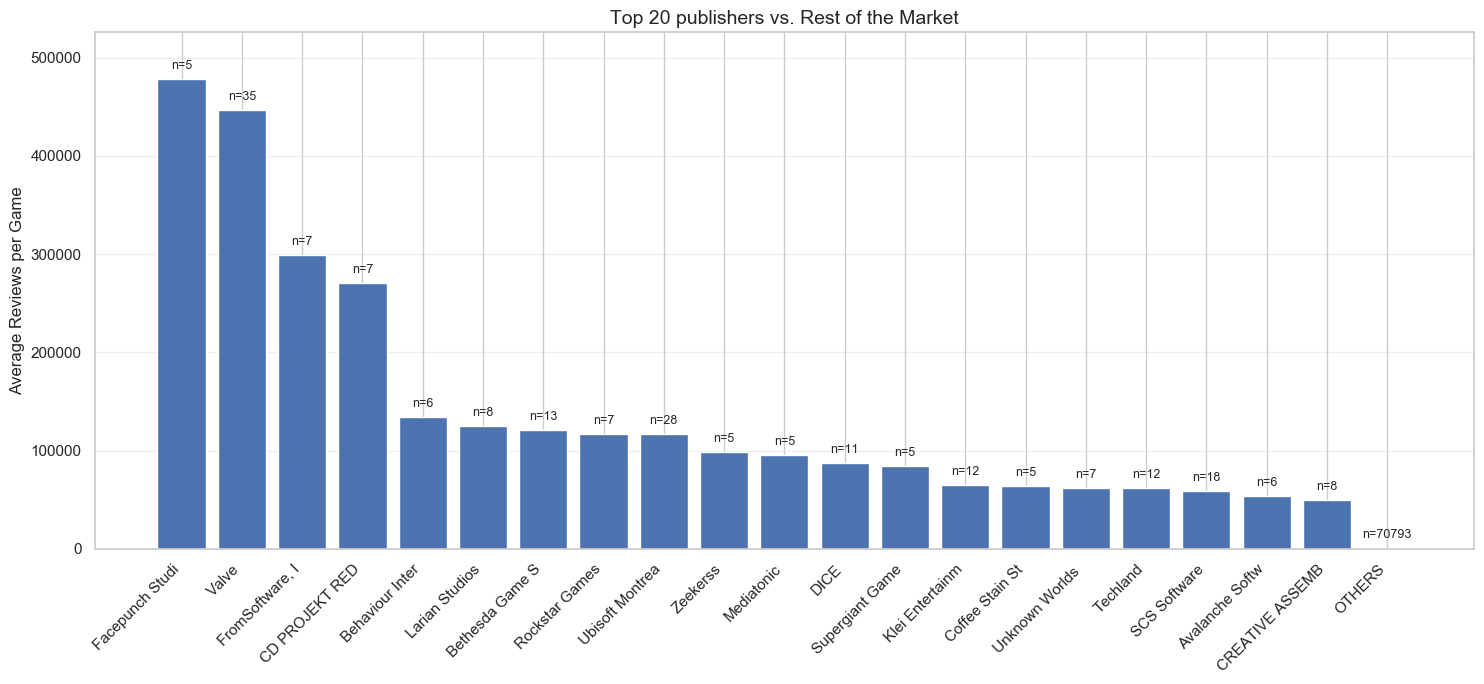

In [594]:
total_reviews = df['Positive'] + df['Negative']

temp_publishers = df['Developers'].fillna('Unknown')
pub_stats = pd.DataFrame({
    'reviews': total_reviews,
    'publisher': temp_publishers
}).groupby('publisher').agg(['mean', 'count'])['reviews']

top_20 = pub_stats[pub_stats['count'] >= 5].sort_values(by='mean', ascending=False).head(20)
others_count = temp_publishers[~temp_publishers.isin(top_20.index)].nunique()
others_mean = total_reviews[~temp_publishers.isin(top_20.index)].mean()

fig, ax = plt.subplots(figsize=(15, 7))

labels = [str(n)[:15] for n in top_20.index] + ['OTHERS']
values = list(top_20['mean']) + [others_mean]
counts = list(top_20['count']) + [others_count]

bars = ax.bar(labels, values)

ax.bar_label(bars, labels=[f'n={c}' for c in counts], padding=5, fontsize=9)

ax.set_title('Top 20 publishers vs. Rest of the Market', fontsize=14)
ax.set_ylabel('Average Reviews per Game')
ax.set_ylim(0, max(values) * 1.1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

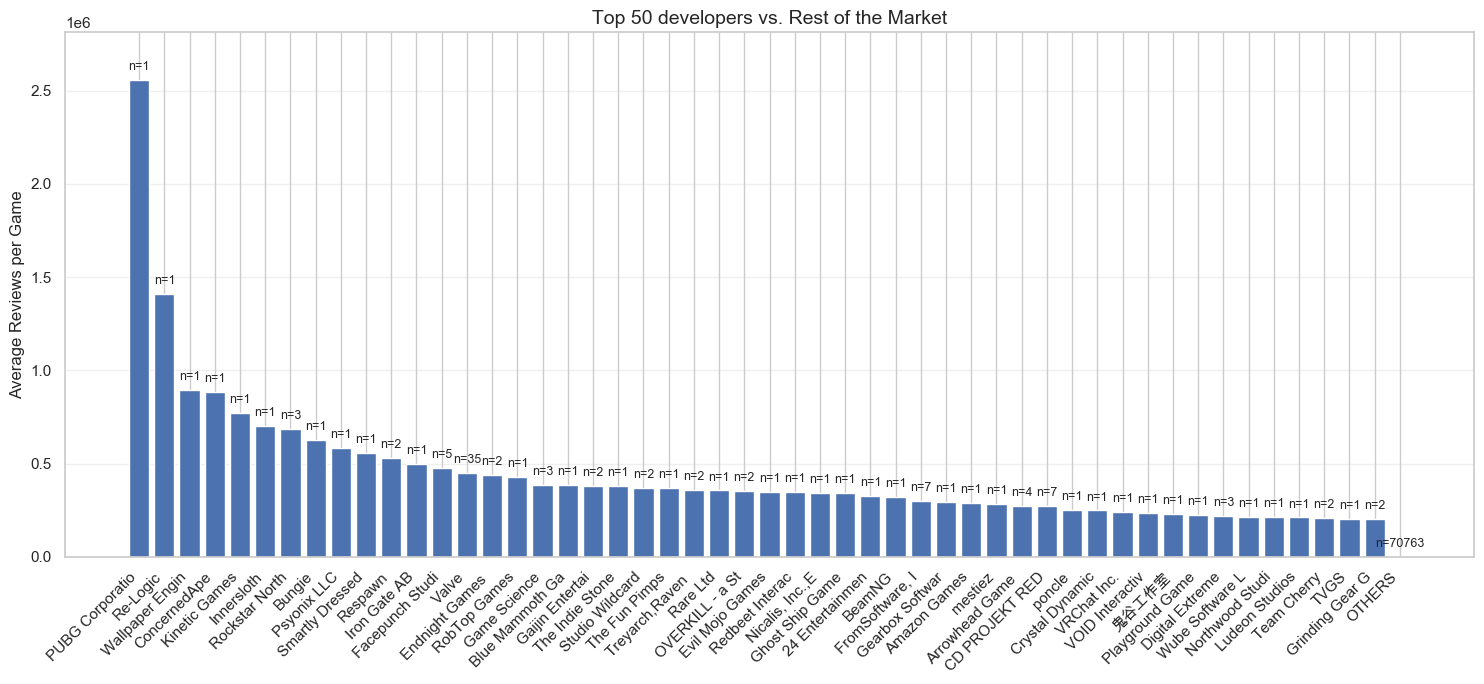

In [595]:
temp_developers = df['Developers'].fillna('Unknown')
pub_stats = pd.DataFrame({
    'reviews': total_reviews,
    'publisher': temp_developers
}).groupby('publisher').agg(['mean', 'count'])['reviews']

top_50 = pub_stats[pub_stats['count'] >= 1].sort_values(by='mean', ascending=False).head(50)
others_count = temp_developers[~temp_developers.isin(top_50.index)].nunique()
others_mean = total_reviews[~temp_developers.isin(top_50.index)].mean()

fig, ax = plt.subplots(figsize=(15, 7))

labels = [str(n)[:15] for n in top_50.index] + ['OTHERS']
values = list(top_50['mean']) + [others_mean]
counts = list(top_50['count']) + [others_count]

bars = ax.bar(labels, values)

ax.bar_label(bars, labels=[f'n={c}' for c in counts], padding=5, fontsize=9)

ax.set_title('Top 50 developers vs. Rest of the Market', fontsize=14)
ax.set_ylabel('Average Reviews per Game')
ax.set_ylim(0, max(values) * 1.1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans'] 
plt.rcParams['axes.unicode_minus'] = False

plt.show()

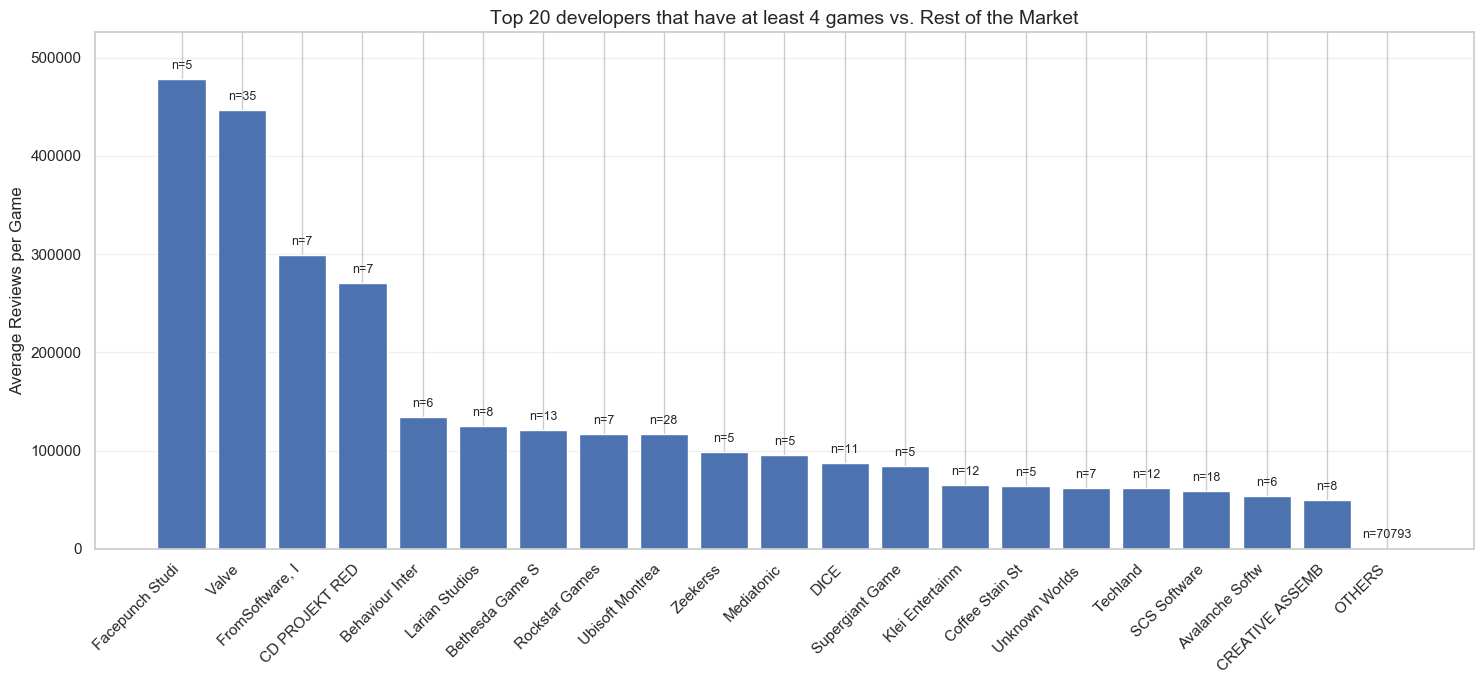

In [596]:
top_20 = pub_stats[pub_stats['count'] >= 5].sort_values(by='mean', ascending=False).head(20)
others_count = temp_developers[~temp_developers.isin(top_20.index)].nunique()
others_mean = total_reviews[~temp_developers.isin(top_20.index)].mean()

fig, ax = plt.subplots(figsize=(15, 7))

labels = [str(n)[:15] for n in top_20.index] + ['OTHERS']
values = list(top_20['mean']) + [others_mean]
counts = list(top_20['count']) + [others_count]

bars = ax.bar(labels, values)

ax.bar_label(bars, labels=[f'n={c}' for c in counts], padding=5, fontsize=9)

ax.set_title('Top 20 developers that have at least 4 games vs. Rest of the Market', fontsize=14)
ax.set_ylabel('Average Reviews per Game')
ax.set_ylim(0, max(values) * 1.1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

We can see that there are two developers with only one game each, but an exceptionally high number of reviews- PUBG Corporation and Re-Logic. Due to their disproportionate influence on review-based metrics, I will treat them as outliers and remove them from the dataset.

In [597]:
df = df[~df['Developers'].isin(['PUBG Corporation', 'Re-Logic'])]

Now let's leave just top 20 developers- those, who have the highest number of positive reviews. Same with publishers.

In [598]:
dev_score = df.groupby('Developers')['Positive'].sum()

top_developers = dev_score.nlargest(50).index.tolist()
df['is_top_developer'] = df['Developers'].apply(lambda x: 1 if x in top_developers else 0)
df.drop(columns=['Developers'], inplace=True)

In [599]:
pub_score = df.groupby('Publishers')['Positive'].sum()
top_publishers = pub_score.nlargest(50).index.tolist()
df['is_top_publisher'] = df['Publishers'].apply(lambda x: 1 if x in top_publishers else 0)
df.drop(columns=['Publishers'], inplace=True)

In [600]:
# Tags, categories, genres
print("Categories:", df["Categories"].unique(), len(df["Categories"].unique()), "\n")
print("Genres:", df["Genres"].unique(), len(df["Genres"].unique()), "\n")
print("Tags:", df["Tags"].unique(), len(df["Tags"].unique()), "\n")

Categories: [nan 'Single-player,Steam Trading Cards,Steam Cloud,Family Sharing'
 'Single-player,Family Sharing' ...
 'Single-player,Steam Achievements,Color Alternatives,Custom Volume Controls,Keyboard Only Option,Playable without Timed Input,Stereo Sound,Steam Cloud,Family Sharing'
 'Single-player,Multi-player,Co-op,Online Co-op,Adjustable Difficulty,Playable without Timed Input,Stereo Sound,Family Sharing'
 'Single-player,Multi-player,PvP,Online PvP,Co-op,Online Co-op,Steam Achievements,Playable without Timed Input,Stereo Sound,Stats,Family Sharing'] 13291 

Genres: [nan 'Adventure' 'Casual' ...
 'Action,Casual,RPG,Simulation,Sports,Strategy,Early Access'
 'Action,Adventure,Casual,Racing,RPG,Sports'
 'Action,Indie,RPG,Simulation,Strategy,Free To Play'] 2895 

Tags: [nan 'Adventure,Visual Novel,Anime,Cute'
 'Casual,Card Game,Solitaire,Puzzle,Hidden Object,2D,Colorful,Stylized,Logic,Mystery,Atmospheric,Family Friendly,PvE,Tutorial,Singleplayer,Tabletop'
 ...
 'Horror,Puzzle,Survival Ho

In [601]:
def split_tags(x):
    if pd.isna(x):
        return []
    return [t.strip() for t in str(x).split(',')]

df['Categories'] = df['Categories'].apply(split_tags)
df['Genres'] = df['Genres'].apply(split_tags)
df['Tags'] = df['Tags'].apply(split_tags)

In [602]:
def impute_genres(row):
    if not row['Genres']:
        return row['Tags']
    return row['Genres']

df['Genres'] = df.apply(impute_genres, axis=1)

In [603]:
def apply_manual_category_mapping(df):
    category_mapping = {
        'has_multiplayer': ['Multi-player', 'Online PvP', 'Online Co-op', 'Cross-Platform Multiplayer', 'MMO', 'PvP', 'Co-op'],
        'has_local_multi': ['Shared/Split Screen', 'Shared/Split Screen Co-op', 'Shared/Split Screen PvP', 'LAN Co-op', 'LAN PvP', 'Remote Play Together'],
        'has_workshop': ['Steam Workshop', 'Includes level editor', 'Mods', 'Mods (require HL2)'],
        'has_achievements': ['Steam Achievements', 'Steam Trading Cards', 'Steam Leaderboards'],
        'has_controller_support': ['Full controller support', 'Partial Controller Support'],
        'has_cloud_saves': ['Steam Cloud'],
        'has_vr': ['VR Support', 'VR Supported', 'VR Only'],
        'has_accessibility_opts': ['Subtitle Options', 'Captions available', 'Adjustable Text Size', 'Color Alternatives', 'Custom Volume Controls', 'Narrated Game Menus'],
        'has_iap': ['In-App Purchases']
    }

    for new_col, keywords in category_mapping.items():
        df[new_col] = df['Categories'].apply(lambda x: 1 if any(k in x for k in keywords) else 0)
    
    return df

df = apply_manual_category_mapping(df)

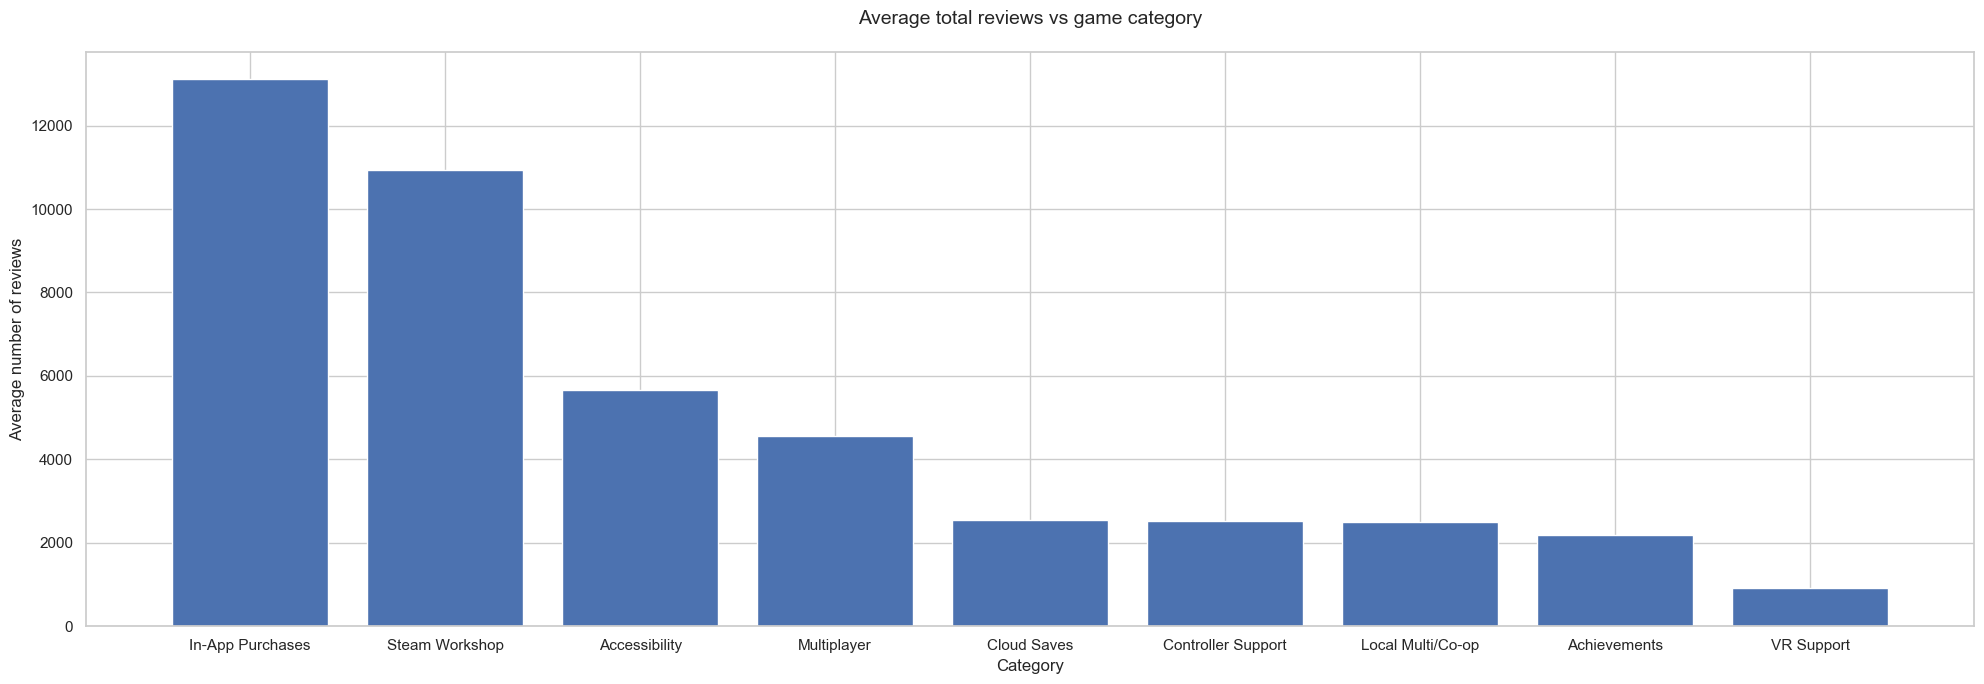

In [604]:
total_reviews = df['Positive'] + df['Negative']

category_cols = {
    'has_multiplayer': 'Multiplayer',
    'has_local_multi': 'Local Multi/Co-op',
    'has_workshop': 'Steam Workshop',
    'has_achievements': 'Achievements',
    'has_controller_support': 'Controller Support',
    'has_cloud_saves': 'Cloud Saves',
    'has_vr': 'VR Support',
    'has_accessibility_opts': 'Accessibility',
    'has_iap': 'In-App Purchases'
}

mean_reviews = {
    name: total_reviews[df[col] == 1].mean() 
    for col, name in category_cols.items()
}
mean_reviews = dict(sorted(mean_reviews.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(20, 7))
bars = plt.bar(mean_reviews.keys(), mean_reviews.values())

plt.title('Average total reviews vs game category', fontsize=14, pad=20)
plt.ylabel('Average number of reviews', fontsize=12)
plt.xlabel('Category', fontsize=12)

plt.tight_layout()
plt.show()

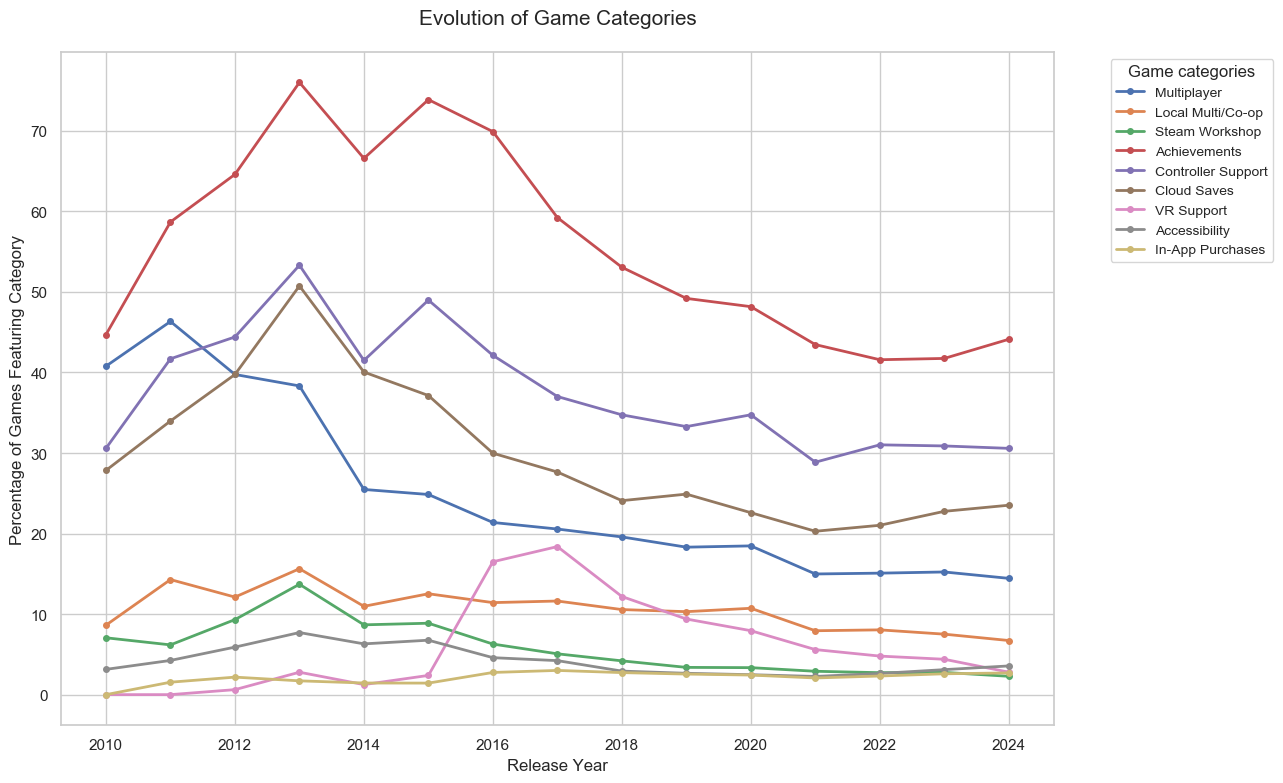

In [605]:
temp_years = pd.to_datetime(df['Release date'], errors='coerce').dt.year

mask_years = (temp_years >= 2010) & (temp_years <= 2024)
filtered_years = temp_years[mask_years]
yearly_total = filtered_years.value_counts().sort_index()

plt.figure(figsize=(13, 8))

for col, label in category_cols.items():
    yearly_top = df[mask_years].groupby(filtered_years)[col].sum()
    trend = (yearly_top / yearly_total) * 100
    
    plt.plot(trend.index, trend.values, label=label, marker='o', markersize=4, linewidth=2)

plt.title('Evolution of Game Categories', fontsize=15, pad=20)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Percentage of Games Featuring Category', fontsize=12)

plt.legend(title='Game categories', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

In [606]:
all_genres = [g for sublist in df['Genres'] for g in sublist]
set(all_genres)

{'1980s',
 "1990's",
 '2.5D',
 '2D',
 '2D Platformer',
 '360 Video',
 '3D',
 '3D Platformer',
 '3D Vision',
 'Abstract',
 'Accounting',
 'Action',
 'Action RPG',
 'Action RTS',
 'Action Roguelike',
 'Action-Adventure',
 'Adventure',
 'Aliens',
 'Alternate History',
 'Animation & Modeling',
 'Anime',
 'Arcade',
 'Artificial Intelligence',
 'Assassin',
 'Asynchronous Multiplayer',
 'Atmospheric',
 'Audio Production',
 'Auto Battler',
 'Automation',
 'Automobile Sim',
 'Base-Building',
 'Based On A Novel',
 'Battle Royale',
 'Beautiful',
 'Benchmark',
 'Board Game',
 'Building',
 'Bullet Hell',
 'Bullet Time',
 'Card Battler',
 'Card Game',
 'Cartoon',
 'Cartoony',
 'Casual',
 'Cats',
 'Character Customization',
 'Chess',
 'Choices Matter',
 'Choose Your Own Adventure',
 'Cinematic',
 'City Builder',
 'Classic',
 'Clicker',
 'Co-op',
 'Collectathon',
 'Colony Sim',
 'Colorful',
 'Combat',
 'Comedy',
 'Comic Book',
 'Competitive',
 'Controller',
 'Conversation',
 'Cooking',
 'Crafting',
 '

In [607]:
genre_mapping = {
    'genre_action': ['Action', 'Shooter', 'FPS', 'Fighting', 'Bullet Hell', 'Hack and Slash', 'Fast-Paced'],
    'genre_rpg': ['RPG', 'Action RPG', 'JRPG', 'Strategy RPG', 'Souls-like', 'Dungeon Crawler'],
    'genre_strategy': ['Strategy', 'RTS', 'Turn-Based Strategy', 'Grand Strategy', 'Tower Defense'],
    'genre_sim_mgmt': ['Simulation', 'Management', 'City Builder', 'Base-Building', 'Economy'],
    'genre_casual_puzzle': ['Casual', 'Puzzle', 'Hidden Object', 'Match 3', 'Logic', 'Board Game'],
    'genre_rogue': ['Rogue-like', 'Rogue-lite', 'Action Roguelike', 'Deckbuilding', 'Roguelike Deckbuilder'],
    'genre_adventure': ['Adventure', 'Open World', 'Metroidvania', 'Exploration', 'Story Rich'],
    'genre_visual_novel': ['Visual Novel', 'Anime', 'Dating Sim', 'Interactive Fiction'],
    'genre_horror': ['Horror', 'Psychological Horror', 'Survival Horror', 'Zombies'],
    'genre_adult': ['Hentai', 'Sexual Content', 'Nudity', 'NSFW'],
    'genre_multiplayer': ['Multiplayer', 'Massively Multiplayer', 'Co-op', 'Online Co-Op', 'PvP', 'Battle Royale']
}

def map_genres_to_meta(genre_list):
    
    found_genres = []
    for genre, keywords in genre_mapping.items():
        if any(k in genre_list for k in keywords):
            found_genres.append(genre)

    return found_genres

meta_genre_assignments = df['Genres'].apply(map_genres_to_meta)

for g_key in genre_mapping.keys():
    df[g_key] = meta_genre_assignments.apply(lambda x: 1 if g_key in x else 0)

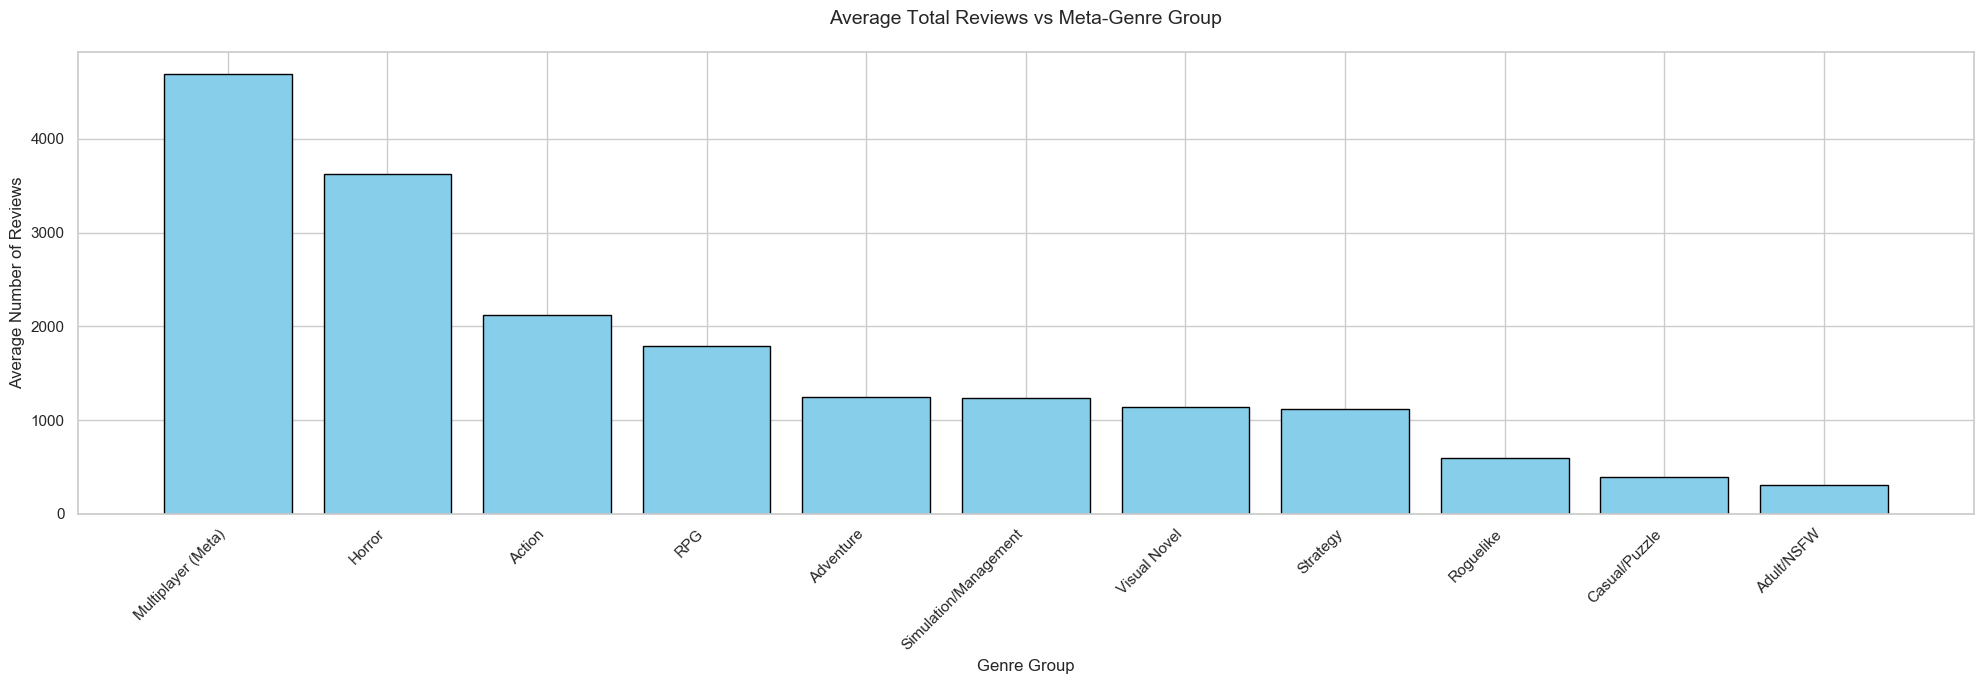

In [608]:
genre_labels = {
    'genre_action': 'Action',
    'genre_rpg': 'RPG',
    'genre_strategy': 'Strategy',
    'genre_sim_mgmt': 'Simulation/Management',
    'genre_casual_puzzle': 'Casual/Puzzle',
    'genre_rogue': 'Roguelike',
    'genre_adventure': 'Adventure',
    'genre_visual_novel': 'Visual Novel',
    'genre_horror': 'Horror',
    'genre_adult': 'Adult/NSFW',
    'genre_multiplayer': 'Multiplayer (Meta)'
}

mean_genre_reviews = {
    label: total_reviews[df[col] == 1].mean() 
    for col, label in genre_labels.items()
}

mean_genre_reviews = dict(sorted(mean_genre_reviews.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(20, 7))
plt.bar(mean_genre_reviews.keys(), mean_genre_reviews.values(), color='skyblue', edgecolor='black')

plt.title('Average Total Reviews vs Meta-Genre Group', fontsize=14, pad=20)
plt.ylabel('Average Number of Reviews', fontsize=12)
plt.xlabel('Genre Group', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

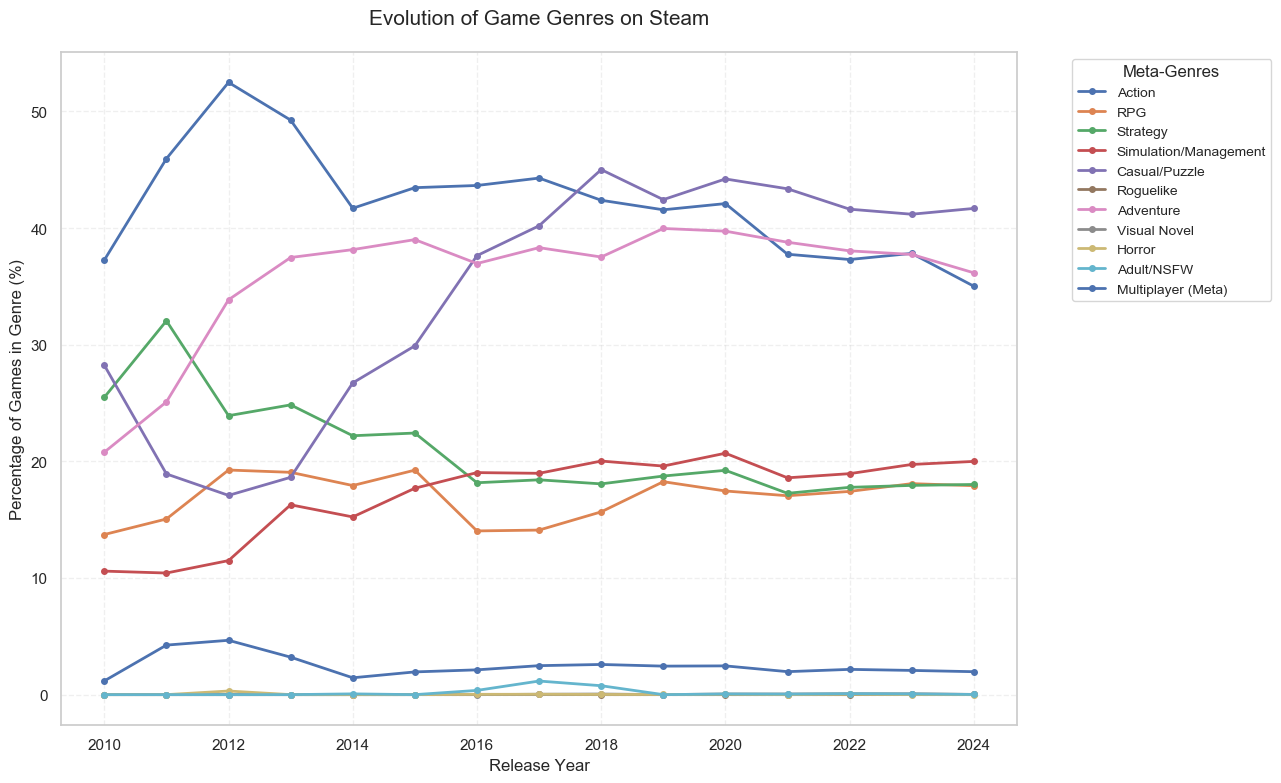

In [609]:

plt.figure(figsize=(13, 8))

for col, label in genre_labels.items():
    yearly_genre_count = df[mask_years].groupby(filtered_years)[col].sum()
    genre_trend = (yearly_genre_count / yearly_total) * 100
    
    plt.plot(genre_trend.index, genre_trend.values, label=label, marker='o', markersize=4, linewidth=2)

plt.title('Evolution of Game Genres on Steam', fontsize=15, pad=20)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Percentage of Games in Genre (%)', fontsize=12)

# Legenda na zewnątrz dla czytelności
plt.legend(title='Meta-Genres', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

"Multiplayer" is currently both in categories and in genres- I will remove the one from genres for two main reasons:
- redundancy: both columns represent the same feature, which can confuse the model,
- data reliability: categories are technical specifications provided by the developer. If a game is listed here as Multiplayer, it means the functional infrastructure (servers, matchmaking) exists. Genres are often community-driven or used for marketing. They are "messier" and can be subjective—for example, a game might be tagged as "multiplayer" simply because it has a leaderboard or something like that.
  

In [610]:
df.drop(columns=['Categories', 'Tags', 'Genres', 'genre_multiplayer'], inplace=True)

In [611]:
# about the game
print(df[df['About the game'].isna()].shape)

(8449, 48)


In [612]:
df[
    ~(df['About the game'].isna()) &
    df['Name'].str.contains('alpha|beta|playtest', case=False, na=False)
].shape

(202, 48)

In [613]:
df[
    (df['About the game'].isna()) &
    ~df['Name'].str.contains('alpha|beta|playtest', case=False, na=False)
].shape

(272, 48)

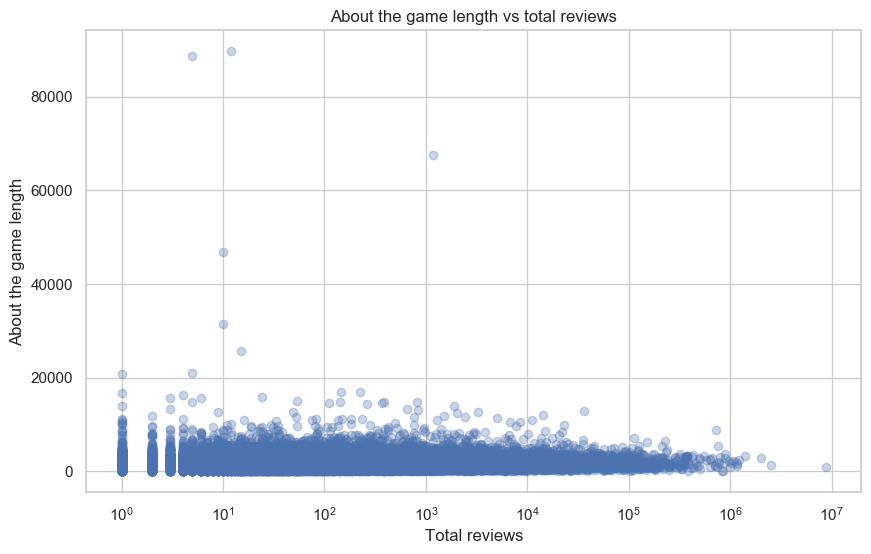

In [614]:
df_plt = df.copy()


df_plt['about_length'] = df_plt['About the game'].str.len().fillna(0)
df_plt['total_reviews'] = df_plt['Positive'] + df_plt['Negative']

df_plt = df_plt.dropna(subset=['about_length', 'total_reviews'])

plt.figure(figsize=(10,6))

plt.scatter(    
    df_plt['total_reviews'],
    df_plt['about_length'],
    alpha=0.3
)

plt.ylabel('About the game length')
plt.xlabel('Total reviews')
plt.title('About the game length vs total reviews')

plt.xscale('log')
plt.show()

In [615]:
def parse_owners(x):
    if pd.isna(x):
        return None
    
    x = x.replace(',', '').replace(' ', '')
    
    low, high = x.split('-')
    return (int(low) + int(high)) / 2

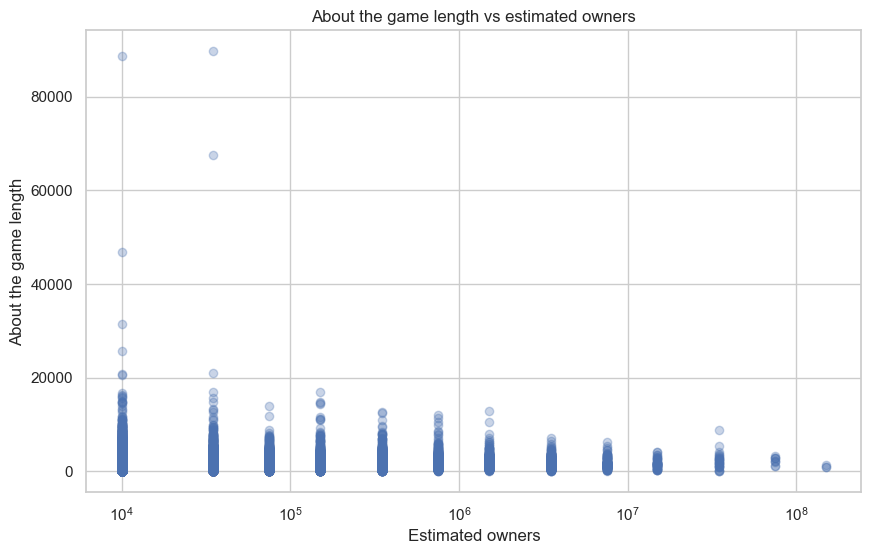

In [616]:
df_plt = df.copy()


df_plt['about_length'] = df_plt['About the game'].str.len().fillna(0)
df_plt['estimated_owners'] = df_plt['Estimated owners'].apply(parse_owners)

df_plt = df_plt.dropna(subset=['about_length', 'estimated_owners'])

plt.figure(figsize=(10,6))

plt.scatter(    
    df_plt['estimated_owners'],
    df_plt['about_length'],
    alpha=0.3
)

plt.ylabel('About the game length')
plt.xlabel('Estimated owners')
plt.title('About the game length vs estimated owners')

plt.xscale('log')
plt.show()

Presence of "About the game" cannot be connected with a game not being a playtest etc. There is a slight interesting corresponding between the length of description and number of reviews or estimated owners- she shorter the description is, the more owners or more reviews it has. I will change the column "About the game" into "About the game len". On the two plots above we can see some outliers so I will also remove them.

In [617]:
df['about_length'] = df['About the game'].str.len().fillna(0)
df = df[df['about_length'] <= 4000]
df.drop(columns='About the game', inplace=True)

I will perform the same analysis on "Name" column.

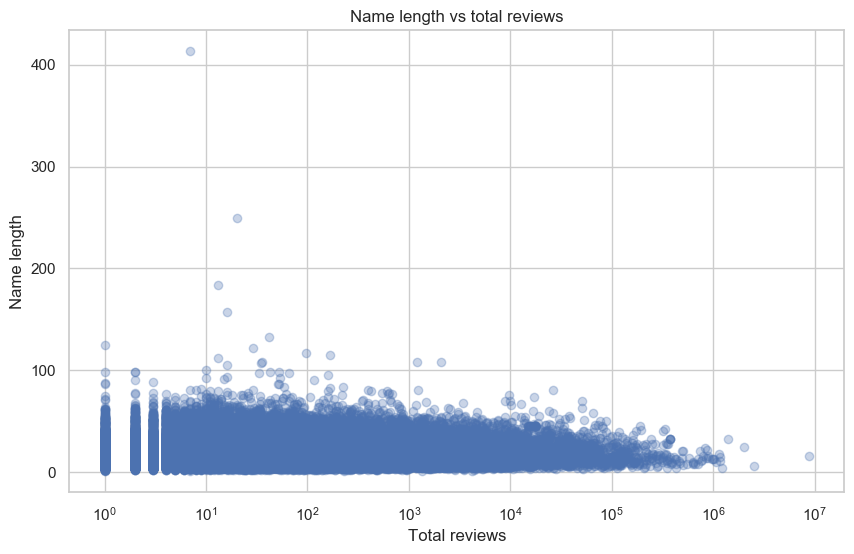

In [618]:
df_plt = df.copy()
df_plt['name_length'] = df_plt['Name'].str.len().fillna(0)
df_plt['total_reviews'] = df_plt['Positive'] + df_plt['Negative']
df_plt = df_plt.dropna(subset=['name_length', 'total_reviews'])
plt.figure(figsize=(10,6))
plt.scatter(
    df_plt['total_reviews'],
    df_plt['name_length'],
    alpha=0.3
)
plt.ylabel('Name length')
plt.xlabel('Total reviews')
plt.title('Name length vs total reviews')
plt.xscale('log')
plt.show()

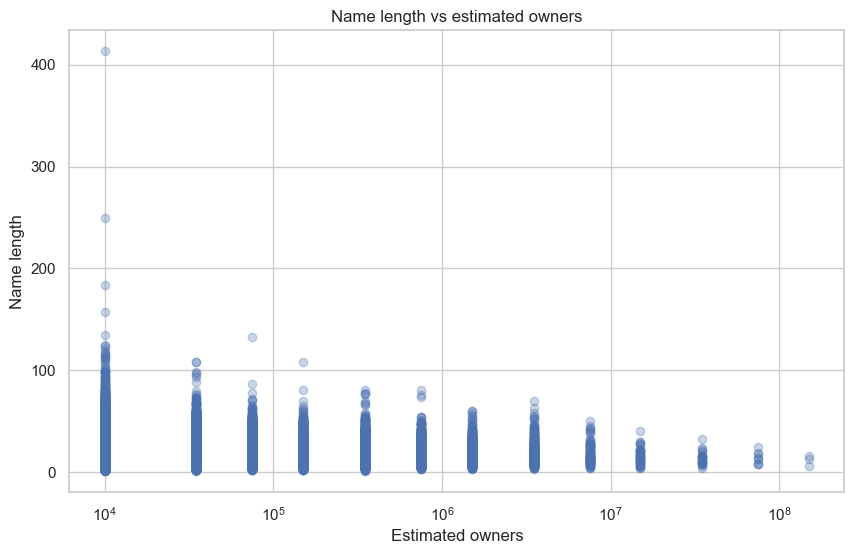

In [619]:
df_plt = df.copy()
df_plt['name_length'] = df_plt['Name'].str.len().fillna(0)
df_plt['estimated_owners'] = df_plt['Estimated owners'].apply(parse_owners)
df_plt = df_plt.dropna(subset=['name_length', 'estimated_owners'])
plt.figure(figsize=(10,6))
plt.scatter(
    df_plt['estimated_owners'],
    df_plt['name_length'],
    alpha=0.3
)
plt.ylabel('Name length')
plt.xlabel('Estimated owners')
plt.title('Name length vs estimated owners')
plt.xscale('log')
plt.show()

We can see a very similar pattern for the "Name" column- shorter names tend to correspond to games with more reviews and more estimated owners. There are also a few visible outliers, so I will remove games with a name length exceeding 150 characters.

In [620]:
df['name_length'] = df['Name'].str.len().fillna(0)
df = df[df['name_length'] <= 150]

Now let's look at the languages.

In [621]:
def get_strategic_languages(x):
    if pd.isna(x):
        return []
    
    x = str(x).replace('\\r', ' ').replace('\\n', ' ')
    prev_x = ""
    while x != prev_x:
        prev_x = x
        x = html.unescape(x)
    
    x = re.sub(r'<.*?>|\[/?b\]|\(.*?\)', ' ', x)
    parts = re.split(r'[,;&\s]{2,}|[,;&]', x)
    
    mapping = {
        'english': 'English',
        'french': 'French',
        'german': 'German',
        'italian': 'Italian',
        'spanish': 'Spanish',
        'portuguese': 'Portuguese',
        'russian': 'Russian',
        'polish': 'Polish',
        'turkish': 'Turkish',
        'japanese': 'Japanese',
        'korean': 'Korean',
        'simplified chinese': 'Chinese',
        'traditional chinese': 'Chinese',
        'chinese': 'Chinese'
    }
    
    cleaned = []
    for p in parts:
        p = p.strip(" '\"[]:.").lower()
        p = re.split(r'\s-\s|\s\(', p)[0]
        
        if p in mapping:
            cleaned.append(mapping[p])
        elif len(p) > 2:
            cleaned.append('Other')
            
    return list(dict.fromkeys(cleaned))


In [622]:
df['lang_list'] = df['Supported languages'].apply(get_strategic_languages)
df['audio_list'] = df['Full audio languages'].apply(get_strategic_languages)

top_langs = ['English', 'French', 'German', 'Italian', 'Spanish', 'Chinese', 'Japanese', 'Korean', 'Russian', 'Portuguese', 'Polish']

for lang in top_langs:
    df[f'lang_{lang}'] = df['lang_list'].apply(lambda x: 1 if lang in x else 0)

for lang in top_langs:
    df[f'has_audio_{lang}'] = df['audio_list'].apply(lambda x: 1 if lang in x else 0)

df['total_lang_count'] = df['lang_list'].apply(len)
df['audio_count'] = df['audio_list'].apply(len)

In [623]:
df.head()

,Name,Release date,Estimated owners,Required age,Price,Discount,DLC count,Supported languages,Full audio languages,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Median playtime forever,has_support_email,has_support_url,has_website,has_reviews,has_header_image,Screenshots_count,is_top_developer,is_top_publisher,has_multiplayer,has_local_multi,has_workshop,has_achievements,has_controller_support,has_cloud_saves,has_vr,has_accessibility_opts,has_iap,genre_action,genre_rpg,genre_strategy,genre_sim_mgmt,genre_casual_puzzle,genre_rogue,genre_adventure,genre_visual_novel,genre_horror,genre_adult,about_length,name_length,lang_list,audio_list,lang_English,lang_French,lang_German,lang_Italian,lang_Spanish,lang_Chinese,lang_Japanese,lang_Korean,lang_Russian,lang_Portuguese,lang_Polish,has_audio_English,has_audio_French,has_audio_German,has_audio_Italian,has_audio_Spanish,has_audio_Chinese,has_audio_Japanese,has_audio_Korean,has_audio_Russian,has_audio_Portuguese,has_audio_Polish,total_lang_count,audio_count
2539430,Black Dragon Mage Playtest,2023-08-01,0 - 0,0,0.00,0,0,[],[],True,False,False,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,26,[],[],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0 - 20000,0,5.24,65,0,['English'],[],True,False,False,0,0,252,3,0,231,8,8,1,1,1,0,1,10,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1626.0,37,[English],[],1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1034400,Mystery Solitaire The Black Raven,2019-05-06,0 - 20000,0,4.99,0,0,"['English', 'French', 'German', 'Russian']",[],True,True,False,0,0,21,3,0,0,0,0,1,1,1,0,1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1178.0,33,"[English, French, German, Russian]",[],1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0
3292190,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,0 - 20000,0,8.99,0,1,['Korean'],['Korean'],True,False,False,0,0,0,0,19,0,0,0,1,0,0,0,1,7,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1827.0,27,[Korean],[Korean],0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1
3631080,Maze Quest VR,2025-04-24,0 - 20000,0,4.99,0,0,['English'],['English'],True,False,False,0,0,0,0,0,0,0,0,1,1,1,0,1,6,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1483.0,13,[English],[English],1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1


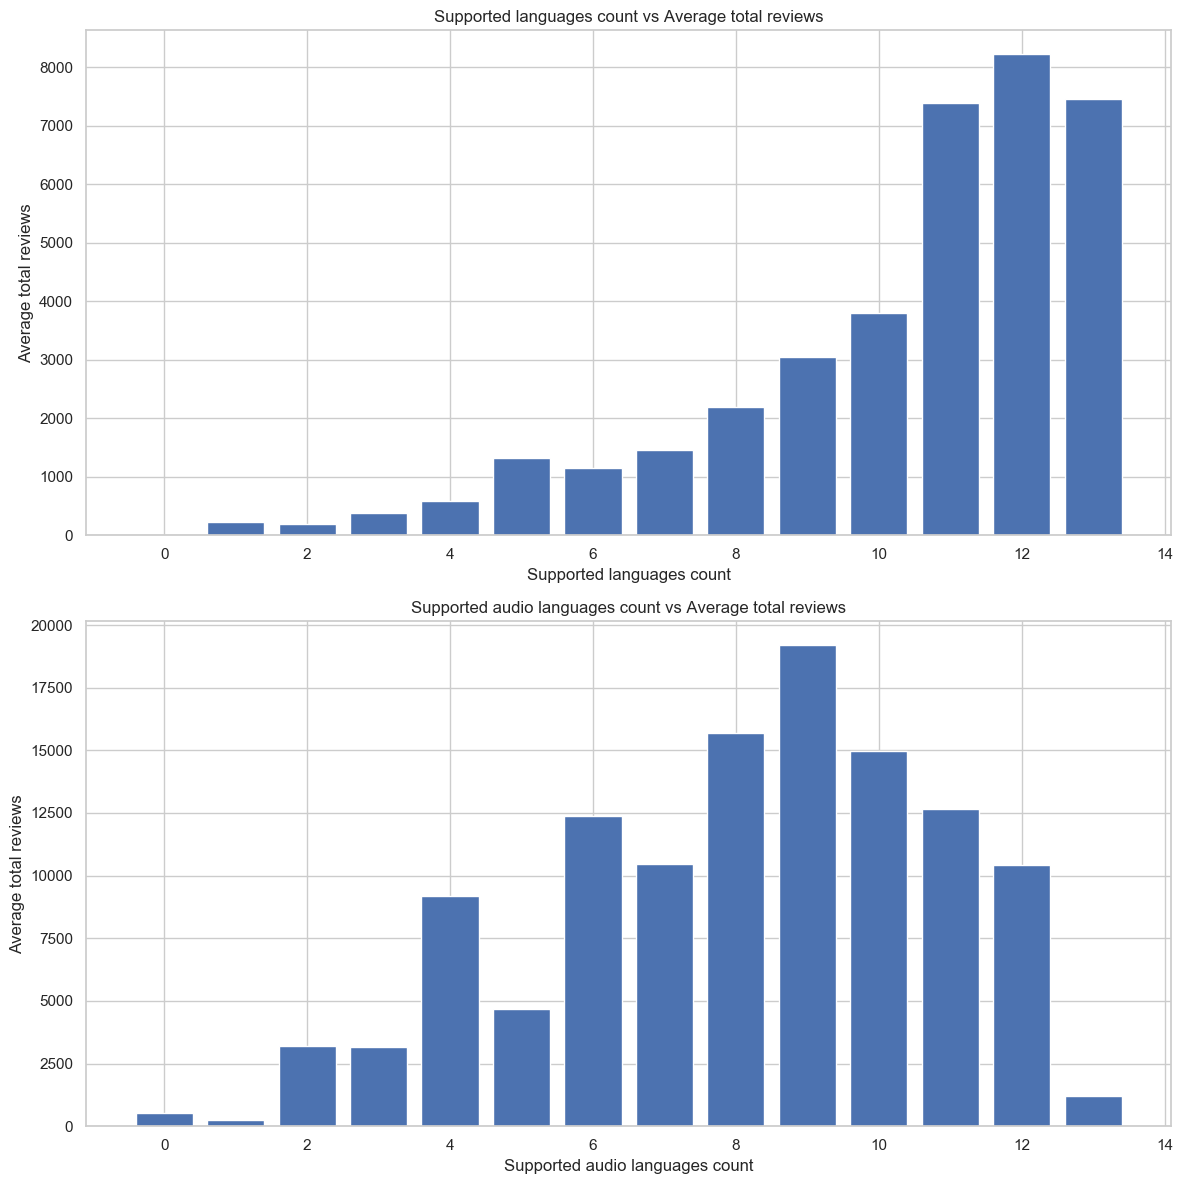

In [624]:
df['total_reviews'] = df['Positive'] + df['Negative']
df['lang_count'] = df['lang_list'].apply(len)
df['audio_count'] = df['audio_list'].apply(len)

stats_lang = df[df['lang_count'] <= 20].groupby('lang_count')['total_reviews'].mean()
stats_audio = df[df['audio_count'] <= 20].groupby('audio_count')['total_reviews'].mean()


plt.figure(figsize=(12, 12))

plt.subplot(2, 1, 1)
plt.bar(stats_lang.index, stats_lang.values)
plt.title('Supported languages count vs Average total reviews')
plt.ylabel('Average total reviews')
plt.xlabel('Supported languages count')

plt.subplot(2, 1, 2)
plt.bar(stats_audio.index, stats_audio.values)
plt.title('Supported audio languages count vs Average total reviews')
plt.xlabel('Supported audio languages count')
plt.ylabel('Average total reviews')

plt.tight_layout()
plt.show()

In [625]:
df.drop(['lang_list', 'audio_list', 'total_reviews', 'Supported languages', 'Full audio languages'], axis=1, inplace=True)

In [626]:
missing = pd.DataFrame({
    'Column': df.columns,
    'Missing': df.isna().sum().values,
    'Percentage': (df.isna().sum() / len(df) * 100).round(2).values
}).sort_values('Percentage', ascending=False).reset_index(drop=True)

missing[missing['Missing'] > 0]

,Column,Missing,Percentage


In [627]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120596 entries, 2539430 to 4141790
Data columns (total 72 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Name                      120596 non-null  object        
 1   Release date              120596 non-null  datetime64[ns]
 2   Estimated owners          120596 non-null  object        
 3   Required age              120596 non-null  int64         
 4   Price                     120596 non-null  float64       
 5   Discount                  120596 non-null  int64         
 6   DLC count                 120596 non-null  int64         
 7   Windows                   120596 non-null  bool          
 8   Mac                       120596 non-null  bool          
 9   Linux                     120596 non-null  bool          
 10  Metacritic score          120596 non-null  int64         
 11  User score                120596 non-null  int64         
 12  

In [628]:
df["Mac"] = df["Mac"].astype(int)
df["Windows"] = df["Windows"].astype(int)
df["Linux"] = df["Linux"].astype(int)

There's also "Estimated owners" column that was left as an objetc. Let's look at it. The bucket '0-0' seems interesting.

In [629]:
df[df['Estimated owners'] == '0 - 0'].head(10)

,Name,Release date,Estimated owners,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Median playtime forever,has_support_email,has_support_url,has_website,has_reviews,has_header_image,Screenshots_count,is_top_developer,is_top_publisher,has_multiplayer,has_local_multi,has_workshop,has_achievements,has_controller_support,has_cloud_saves,has_vr,has_accessibility_opts,has_iap,genre_action,genre_rpg,genre_strategy,genre_sim_mgmt,genre_casual_puzzle,genre_rogue,genre_adventure,genre_visual_novel,genre_horror,genre_adult,about_length,name_length,lang_English,lang_French,lang_German,lang_Italian,lang_Spanish,lang_Chinese,lang_Japanese,lang_Korean,lang_Russian,lang_Portuguese,lang_Polish,has_audio_English,has_audio_French,has_audio_German,has_audio_Italian,has_audio_Spanish,has_audio_Chinese,has_audio_Japanese,has_audio_Korean,has_audio_Russian,has_audio_Portuguese,has_audio_Polish,total_lang_count,audio_count,lang_count
2539430,Black Dragon Mage Playtest,2023-08-01,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1946890,Codename: Warlock Playtest,2022-03-25,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2260230,Midnight Dash,2023-01-09,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,17,0,0,0,1,0,0,0,1,10,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,898.0,13,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1
2713630,Black Market,2025-01-24,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,892.0,12,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
2349750,CyberVault Playtest,2023-03-08,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,3,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2628280,A Night In Omar's Burger Playtest,2023-10-04,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,33,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2731180,Blaster Multiplayer,2024-01-02,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,7,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1576.0,19,1,1,1,1,1,0,1,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,9,2,9
3854040,BRUTALISMUS: Dystopia,2025-07-31,0 - 0,0,1.39,0,1,1,1,1,0,0,0,0,1,0,0,0,1,0,0,0,1,24,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,1,0,0,0,1793.0,21,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1
2310500,Ortheo's Interdimensional Jam Session,2023-08-10,0 - 0,0,0.00,0,0,1,1,0,0,0,0,0,13,0,0,0,1,1,1,0,1,5,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2591.0,37,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1
2641000,Spider-Guy: Trapped in the Cheese Place,2024-02-21,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,6,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,442.0,39,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,13,13,13


In [630]:
def format_owners(range_str):
    if pd.isna(range_str):
        return range_str
    
    upper = int(range_str.split('-')[1])
    lower = int(range_str.split('-')[0])

    result = ""

    if lower >= 1_000_000:
        result += f"{lower // 1_000_000}M - "
    elif lower >= 1_000:
        result += f"{lower // 1_000}K - "
    else:
        result += f'{str(lower)} - '
    
    if upper >= 1_000_000:
        result += f"{upper // 1_000_000}M"
    elif upper >= 1_000:
        result += f"{upper // 1_000}K"
    else:
        result += str(upper)

    return result   

In [631]:
owners_counts = df['Estimated owners'].value_counts().reset_index()
owners_counts.columns = ['Estimated owners', 'Number of games']

owners_counts['Estimated owners'] = owners_counts['Estimated owners'].apply(format_owners)
owners_counts

,Estimated owners,Number of games
0,0 - 20K,74242
1,0 - 0,21479
2,20K - 50K,11149
3,50K - 100K,5218
4,100K - 200K,3354
5,200K - 500K,2752
6,500K - 1M,1104
7,1M - 2M,700
8,2M - 5M,390
9,5M - 10M,120


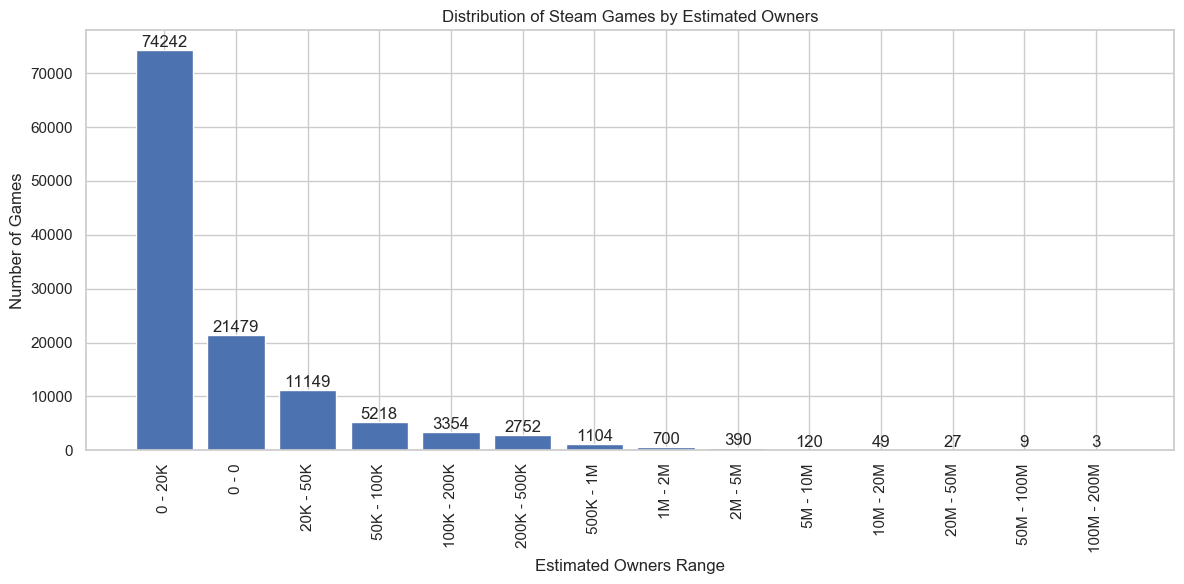

In [632]:
plt.figure(figsize=(12, 6))
plt.bar(
    owners_counts['Estimated owners'],
    owners_counts['Number of games'],
)

plt.xlabel("Estimated Owners Range")
plt.ylabel("Number of Games")
plt.title("Distribution of Steam Games by Estimated Owners")
plt.xticks(rotation=90)

for i, v in enumerate(owners_counts['Number of games']):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [633]:
cond_00_owners_playtest = (df['Estimated owners'] == '0 - 0') & \
                  (df['Name'].str.contains('playtest|alpha|beta|trial|demo|demo version', case=False, na=False) )

In [634]:
df [ cond_00_owners_playtest]

,Name,Release date,Estimated owners,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Median playtime forever,has_support_email,has_support_url,has_website,has_reviews,has_header_image,Screenshots_count,is_top_developer,is_top_publisher,has_multiplayer,has_local_multi,has_workshop,has_achievements,has_controller_support,has_cloud_saves,has_vr,has_accessibility_opts,has_iap,genre_action,genre_rpg,genre_strategy,genre_sim_mgmt,genre_casual_puzzle,genre_rogue,genre_adventure,genre_visual_novel,genre_horror,genre_adult,about_length,name_length,lang_English,lang_French,lang_German,lang_Italian,lang_Spanish,lang_Chinese,lang_Japanese,lang_Korean,lang_Russian,lang_Portuguese,lang_Polish,has_audio_English,has_audio_French,has_audio_German,has_audio_Italian,has_audio_Spanish,has_audio_Chinese,has_audio_Japanese,has_audio_Korean,has_audio_Russian,has_audio_Portuguese,has_audio_Polish,total_lang_count,audio_count,lang_count
2539430,Black Dragon Mage Playtest,2023-08-01,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1946890,Codename: Warlock Playtest,2022-03-25,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2349750,CyberVault Playtest,2023-03-08,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,3,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2628280,A Night In Omar's Burger Playtest,2023-10-04,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,33,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2689730,Dark and Deep Playtest,2024-03-20,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2003950,Goblin Gladiators Playtest,2022-08-08,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1692440,Solys Playtest,2021-08-06,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3830800,Monster Truck Demolition Derby,2026-01-01,0 - 0,0,2.99,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,5,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,707.0,30,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
3659430,Way of the Dragons Playtest,2025-04-12,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,12,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,27,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


There are over 21,000 games with an "0 - 0" estimated owners bucket. Around 8,000 of them are playtests or demo versions- not full released games- which also generate numerous outliers due to almost all their column values being missing. I will remove them from the dataset.

In [635]:
df = df[~cond_00_owners_playtest]

In [636]:
df[df['Estimated owners'] == '0 - 0'].head(50)

,Name,Release date,Estimated owners,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Median playtime forever,has_support_email,has_support_url,has_website,has_reviews,has_header_image,Screenshots_count,is_top_developer,is_top_publisher,has_multiplayer,has_local_multi,has_workshop,has_achievements,has_controller_support,has_cloud_saves,has_vr,has_accessibility_opts,has_iap,genre_action,genre_rpg,genre_strategy,genre_sim_mgmt,genre_casual_puzzle,genre_rogue,genre_adventure,genre_visual_novel,genre_horror,genre_adult,about_length,name_length,lang_English,lang_French,lang_German,lang_Italian,lang_Spanish,lang_Chinese,lang_Japanese,lang_Korean,lang_Russian,lang_Portuguese,lang_Polish,has_audio_English,has_audio_French,has_audio_German,has_audio_Italian,has_audio_Spanish,has_audio_Chinese,has_audio_Japanese,has_audio_Korean,has_audio_Russian,has_audio_Portuguese,has_audio_Polish,total_lang_count,audio_count,lang_count
2260230,Midnight Dash,2023-01-09,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,17,0,0,0,1,0,0,0,1,10,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,898.0,13,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1
2713630,Black Market,2025-01-24,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,892.0,12,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
2731180,Blaster Multiplayer,2024-01-02,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,7,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1576.0,19,1,1,1,1,1,0,1,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,9,2,9
3854040,BRUTALISMUS: Dystopia,2025-07-31,0 - 0,0,1.39,0,1,1,1,1,0,0,0,0,1,0,0,0,1,0,0,0,1,24,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,1,0,0,0,1793.0,21,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1
2310500,Ortheo's Interdimensional Jam Session,2023-08-10,0 - 0,0,0.00,0,0,1,1,0,0,0,0,0,13,0,0,0,1,1,1,0,1,5,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2591.0,37,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1
2641000,Spider-Guy: Trapped in the Cheese Place,2024-02-21,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,6,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,442.0,39,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,13,13,13
3797720,謎解き二十部屋,2025-07-09,0 - 0,0,4.79,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,5,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,503.0,7,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
3491950,Food Truck Monopoly,2025-07-13,0 - 0,0,0.99,0,0,1,0,0,0,0,0,0,8,0,0,0,1,0,0,0,1,5,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,491.0,19,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1
4063660,Chronosurge: Echoes of the Void,2025-10-17,0 - 0,0,0.99,0,0,1,0,0,0,0,0,0,23,0,0,0,1,1,0,0,1,6,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,2019.0,31,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
3976870,Rowen's Grand Adventure,2025-09-30,0 - 0,0,11.69,0,0,1,0,0,0,0,0,0,22,0,0,0,1,0,0,0,1,5,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1203.0,23,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1


I googled some of the remaining games with 0-0 estimated owners. Some fo them are playtest, some of them are removed from steam and some of them are available to play. It would be too hard to analyze each game manually, so I will leave them in the dataset, but change their 'estimated owners' value to 0-2000 to place them in the lowest reasonable bucket

In [638]:
df['Estimated owners'] = df['Estimated owners'].replace('0 - 0', '0 - 2000')

Now I will turn buckets into an categorical ordinal feature.

In [640]:
def get_median_owners(x):
    low, high = x.replace(',', '').replace(' ', '').split('-')
    return (int(low) + int(high)) / 2

df['Estimated owners'] = df['Estimated owners'].apply(get_median_owners)
df.drop(columns='Name', inplace=True)

### Outliers

In [642]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112294 entries, 496350 to 4141790
Data columns (total 71 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Release date              112294 non-null  datetime64[ns]
 1   Estimated owners          112294 non-null  float64       
 2   Required age              112294 non-null  int64         
 3   Price                     112294 non-null  float64       
 4   Discount                  112294 non-null  int64         
 5   DLC count                 112294 non-null  int64         
 6   Windows                   112294 non-null  int64         
 7   Mac                       112294 non-null  int64         
 8   Linux                     112294 non-null  int64         
 9   Metacritic score          112294 non-null  int64         
 10  User score                112294 non-null  int64         
 11  Positive                  112294 non-null  int64         
 12  N

In [643]:
COLUMNS_TO_CHECK = [
    'year', 'Required age', 'Price', 'Discount', 'DLC count',
    'Metacritic score', 'User score', 'Positive', 'Negative',
    'Achievements', 'Recommendations', 'Average playtime forever',
    'Median playtime forever', 'Screenshots_count',
]

BOUNDED_COLUMNS = {
    'Discount': (0, 100),
}


def analyze_outliers(df: pd.DataFrame,
                     col: str,
                     iqr_multiplier: float = 1.5,
                     figsize: tuple = (10, 6)) -> dict:

    series = df[col].dropna()

    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr    = q3 - q1
    mn, mx = series.min(), series.max()
    skew   = series.skew()

    if col in BOUNDED_COLUMNS:
        lo, hi = BOUNDED_COLUMNS[col]
    else:
        lo = max(q1 - iqr_multiplier * iqr, 0) if mn >= 0 else q1 - iqr_multiplier * iqr
        hi = q3 + iqr_multiplier * iqr

    outlier_mask = df[col].notna() & ((df[col] < lo) | (df[col] > hi))
    n_out   = outlier_mask.sum()
    pct_out = n_out / len(df) * 100

    n_bins = min(80, max(20, int(len(series) ** 0.45)))

    # log series (only if all values >= 0)
    can_log = mn >= 0
    series_log = np.log1p(series) if can_log else None
    lo_log     = np.log1p(lo)     if can_log else None
    hi_log     = np.log1p(hi)     if can_log else None

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(col, fontsize=12)
    ax_box, ax_box_log, ax_hist, ax_hist_log = axes.flat

    # ── Normal boxplot ─────────────────────────────────────────────
    ax_box.boxplot(series, vert=False)
    ax_box.axvline(lo, color='red', linestyle='--', linewidth=1, label=f'IQR × {iqr_multiplier}')
    ax_box.axvline(hi, color='red', linestyle='--', linewidth=1)
    ax_box.set_yticks([])
    ax_box.set_xlabel('Value')
    ax_box.set_title('Boxplot')
    ax_box.legend(fontsize=8)

    # ── Log boxplot ────────────────────────────────────────────────
    if can_log:
        ax_box_log.boxplot(series_log, vert=False)
        ax_box_log.axvline(lo_log, color='red', linestyle='--', linewidth=1, label=f'IQR × {iqr_multiplier}')
        ax_box_log.axvline(hi_log, color='red', linestyle='--', linewidth=1)
        ax_box_log.set_yticks([])
        ax_box_log.set_xlabel('log(1+x)')
        ax_box_log.set_title('Boxplot [log]')
        ax_box_log.legend(fontsize=8)
    else:
        ax_box_log.axis('off')
        ax_box_log.text(0.5, 0.5, 'log not available\n(negative values)',
                        ha='center', va='center', transform=ax_box_log.transAxes)

    # ── Normal histogram ───────────────────────────────────────────
    ax_hist.hist(series, bins=n_bins, color='steelblue', alpha=0.7)
    ax_hist.axvline(lo, color='red', linestyle='--', linewidth=1, label='bounds')
    ax_hist.axvline(hi, color='red', linestyle='--', linewidth=1)
    ax_hist.set_xlabel('Value')
    ax_hist.set_ylabel('Count')
    ax_hist.set_title('Histogram')
    ax_hist.legend(fontsize=8)

    # ── Log histogram ──────────────────────────────────────────────
    if can_log:
        ax_hist_log.hist(series_log, bins=n_bins, color='steelblue', alpha=0.7)
        ax_hist_log.axvline(lo_log, color='red', linestyle='--', linewidth=1, label='bounds')
        ax_hist_log.axvline(hi_log, color='red', linestyle='--', linewidth=1)
        ax_hist_log.set_xlabel('log(1+x)')
        ax_hist_log.set_ylabel('Count')
        ax_hist_log.set_title('Histogram [log]')
        ax_hist_log.legend(fontsize=8)
    else:
        ax_hist_log.axis('off')

    plt.tight_layout()
    plt.show()

    print(f'[{col}]  outliers: {n_out} ({pct_out:.2f}%)  |  bounds: [{lo:.2f}, {hi:.2f}]  |  min/max: {mn:.2f}/{mx:.2f}  |  skew: {skew:.2f}')

    return {
        'col': col, 'n_outliers': n_out, 'pct_outliers': pct_out,
        'lower_bound': lo, 'upper_bound': hi, 'outlier_mask': outlier_mask,
        'stats': {'q1': q1, 'q3': q3, 'iqr': iqr, 'skew': skew, 'min': mn, 'max': mx},
    }


def analyze_all(df: pd.DataFrame,
                columns: list[str] | None = None,
                iqr_multiplier: float = 1.5) -> pd.DataFrame:
    if columns is None:
        columns = [c for c in COLUMNS_TO_CHECK if c in df.columns]

    missing = [c for c in COLUMNS_TO_CHECK if c not in df.columns]
    if missing:
        print(f'Columns not found: {missing}\n')

    rows = []
    for col in columns:
        r = analyze_outliers(df, col, iqr_multiplier=iqr_multiplier)
        if r:
            rows.append({
                'Column':      r['col'],
                'N outliers':  r['n_outliers'],
                '% outliers':  round(r['pct_outliers'], 2),
                'Lower bound': round(r['lower_bound'], 2),
                'Upper bound': round(r['upper_bound'], 2),
                'Skewness':    round(r['stats']['skew'], 2),
                'Min':         round(r['stats']['min'], 2),
                'Max':         round(r['stats']['max'], 2),
            })

    summary = pd.DataFrame(rows).set_index('Column')
    return summary



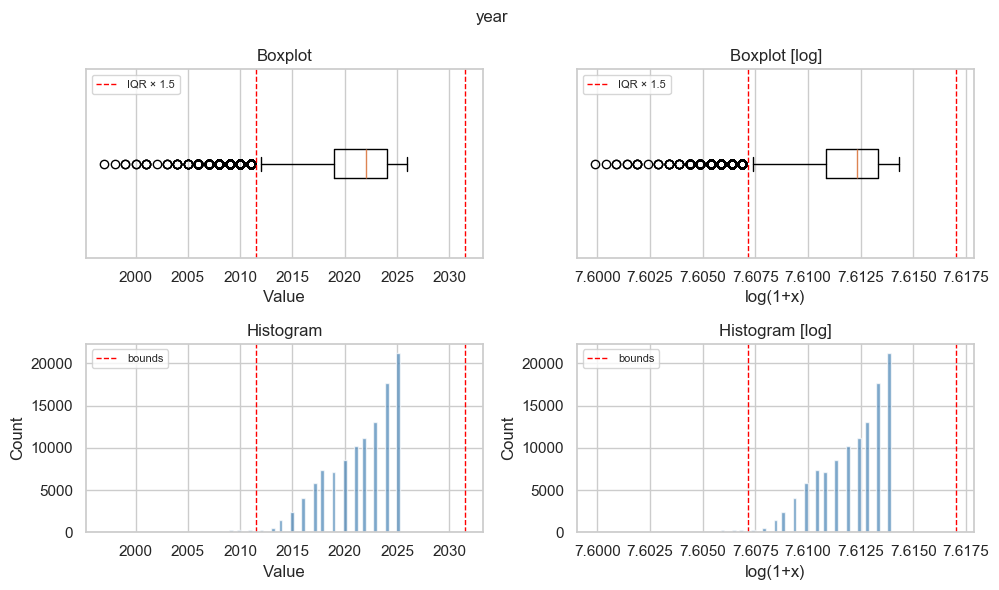

[year]  outliers: 1165 (1.04%)  |  bounds: [2011.50, 2031.50]  |  min/max: 1997.00/2026.00  |  skew: -1.03


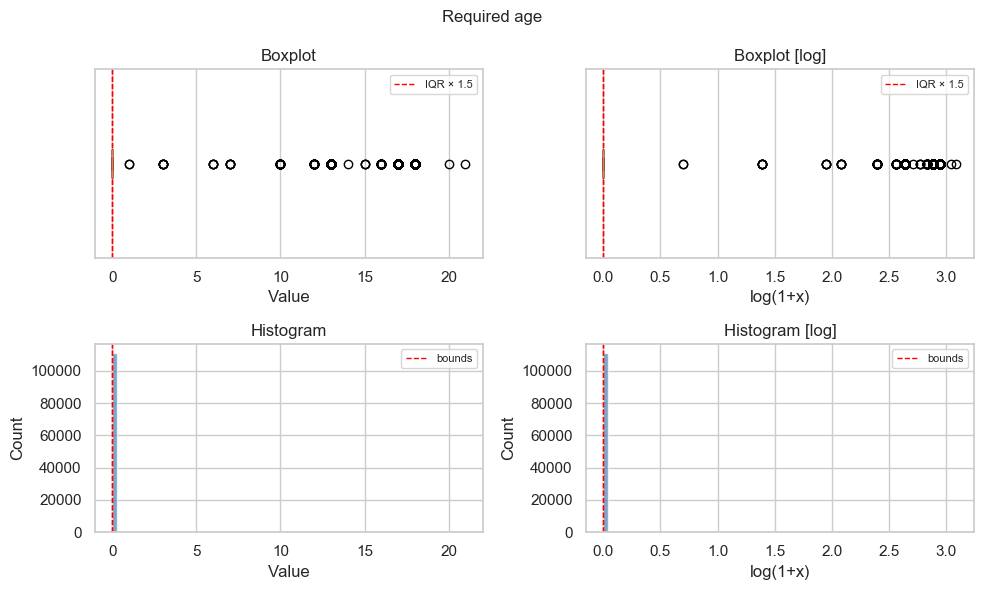

[Required age]  outliers: 1244 (1.11%)  |  bounds: [0.00, 0.00]  |  min/max: 0.00/21.00  |  skew: 9.55


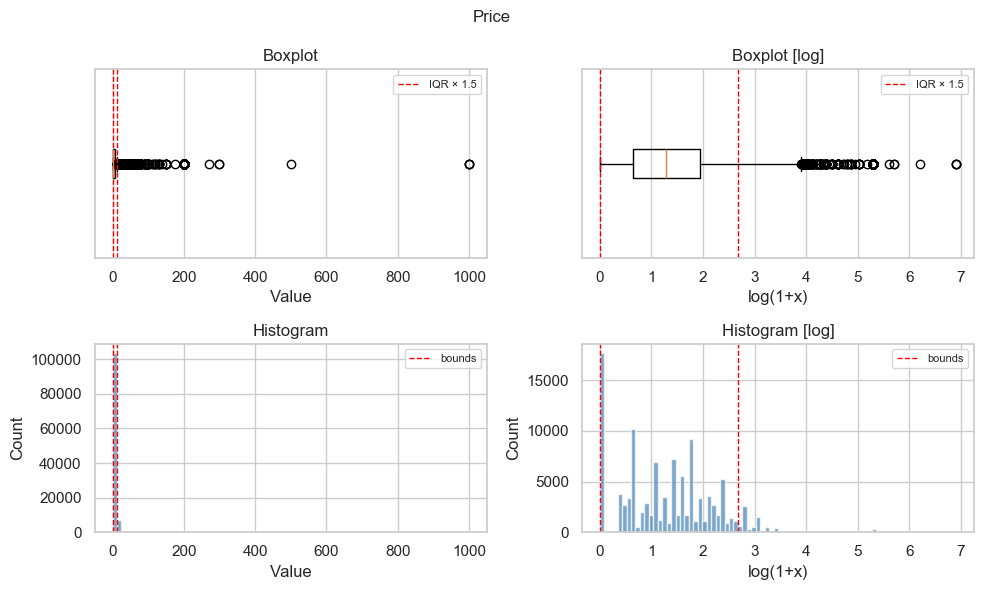

[Price]  outliers: 7626 (6.79%)  |  bounds: [0.00, 13.64]  |  min/max: 0.00/999.98  |  skew: 22.17


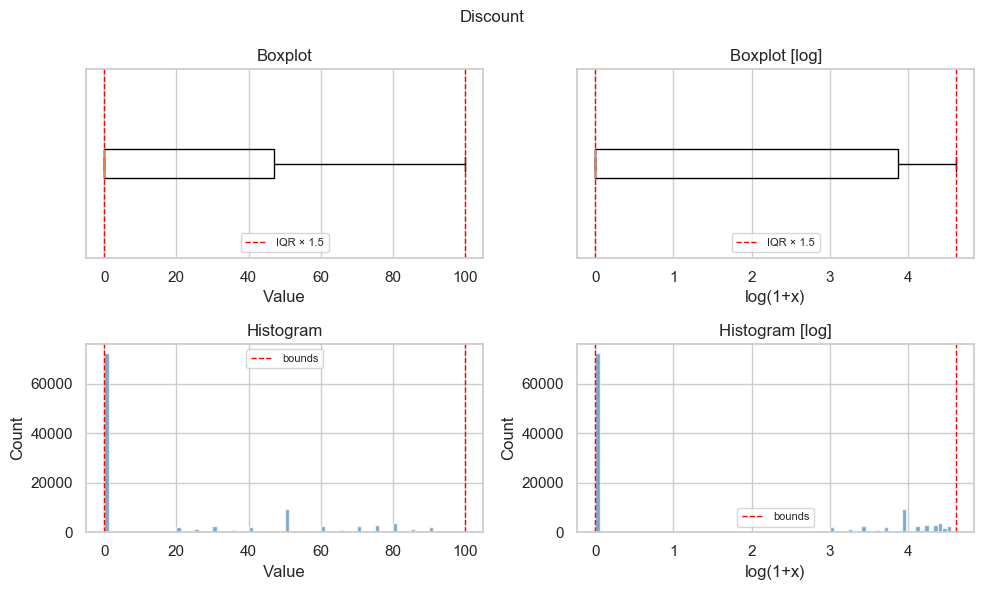

[Discount]  outliers: 0 (0.00%)  |  bounds: [0.00, 100.00]  |  min/max: 0.00/100.00  |  skew: 1.12


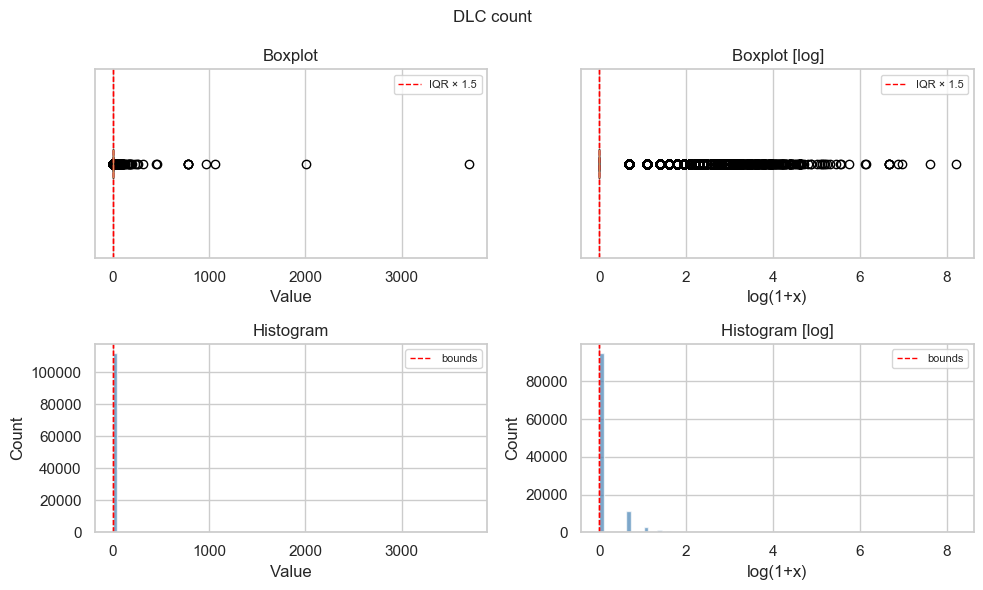

[DLC count]  outliers: 17205 (15.32%)  |  bounds: [0.00, 0.00]  |  min/max: 0.00/3703.00  |  skew: 173.67


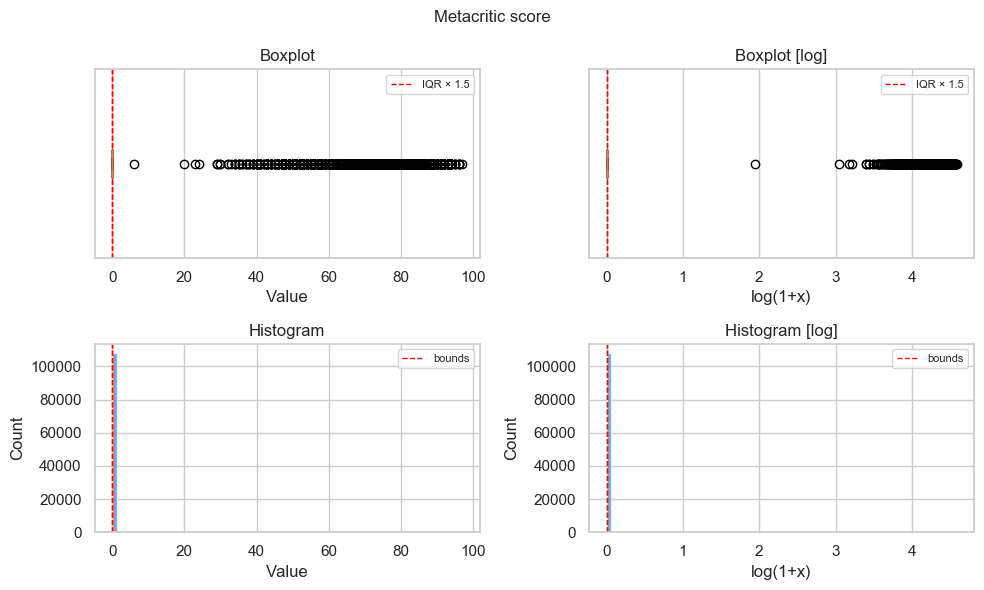

[Metacritic score]  outliers: 4152 (3.70%)  |  bounds: [0.00, 0.00]  |  min/max: 0.00/97.00  |  skew: 5.05


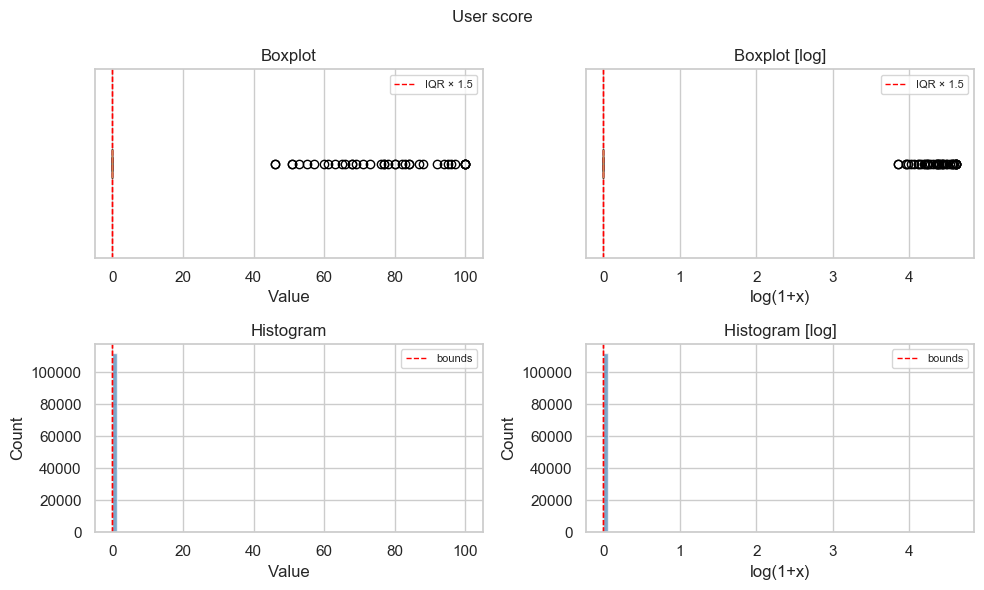

[User score]  outliers: 39 (0.03%)  |  bounds: [0.00, 0.00]  |  min/max: 0.00/100.00  |  skew: 57.04


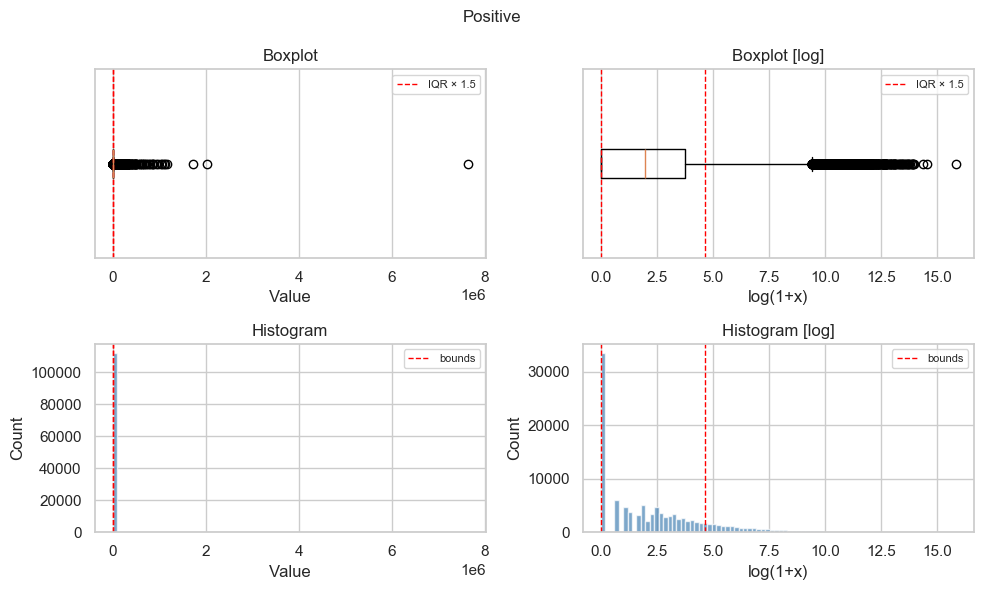

[Positive]  outliers: 19002 (16.92%)  |  bounds: [0.00, 105.00]  |  min/max: 0.00/7642084.00  |  skew: 182.91


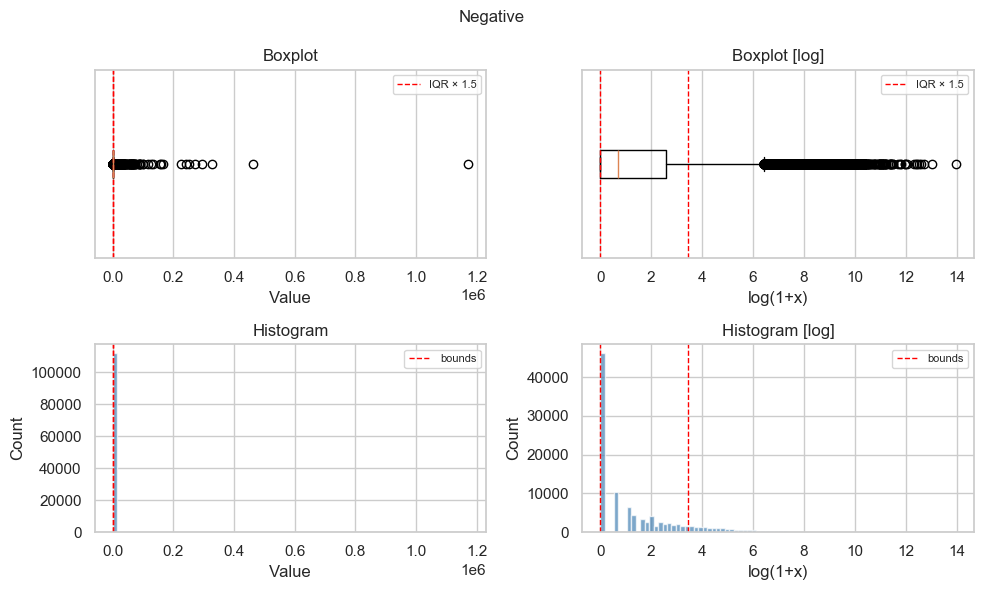

[Negative]  outliers: 18369 (16.36%)  |  bounds: [0.00, 30.00]  |  min/max: 0.00/1173003.00  |  skew: 165.04


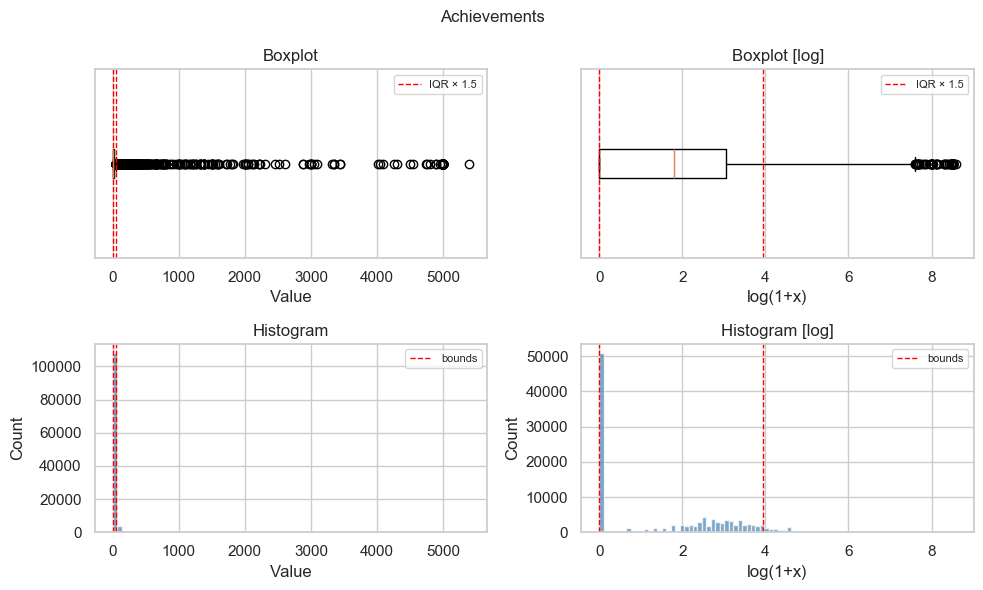

[Achievements]  outliers: 6844 (6.09%)  |  bounds: [0.00, 50.00]  |  min/max: 0.00/5394.00  |  skew: 30.67


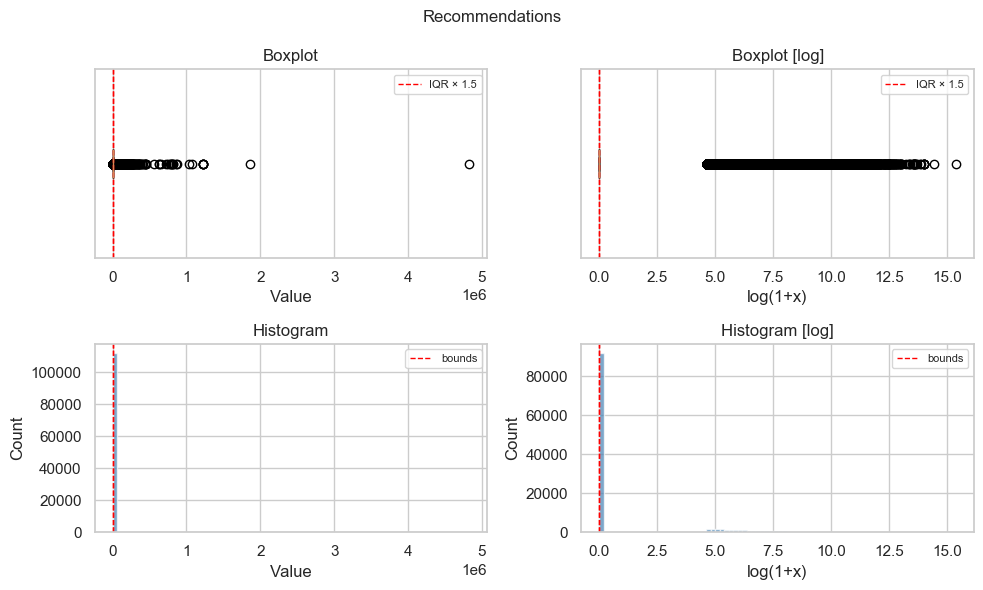

[Recommendations]  outliers: 20223 (18.01%)  |  bounds: [0.00, 0.00]  |  min/max: 0.00/4830455.00  |  skew: 119.87


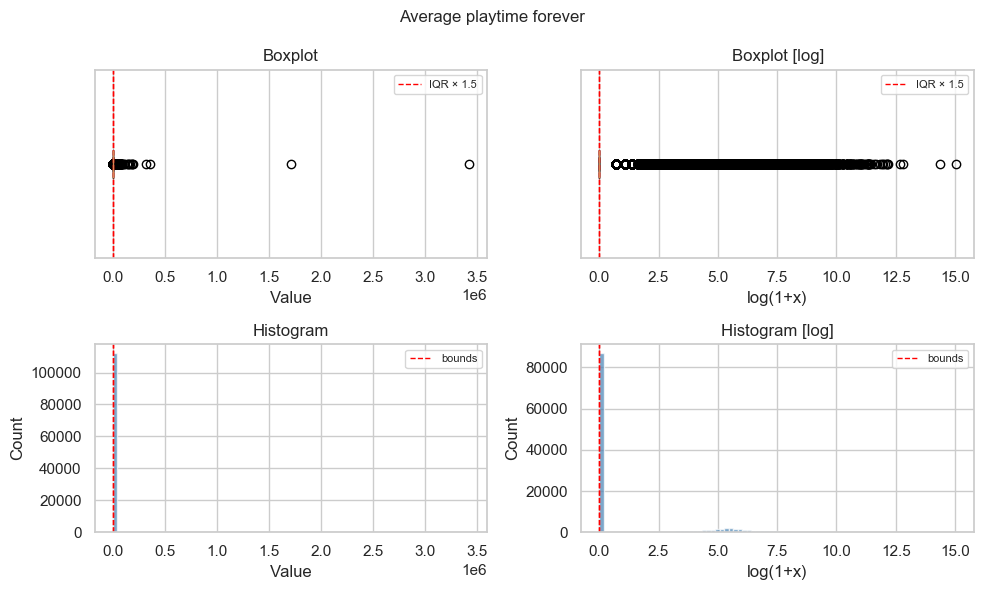

[Average playtime forever]  outliers: 25339 (22.56%)  |  bounds: [0.00, 0.00]  |  min/max: 0.00/3429544.00  |  skew: 252.43


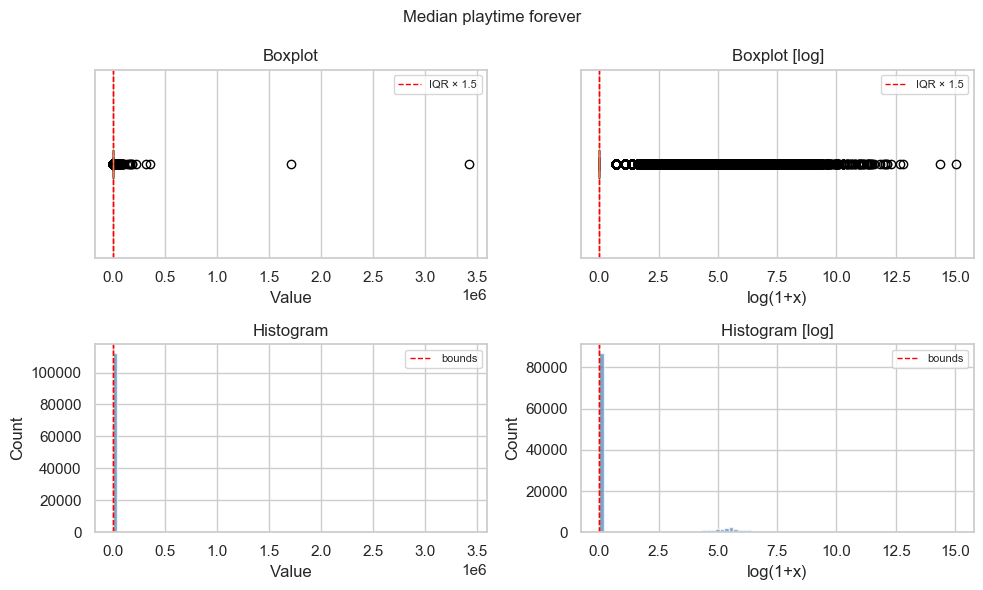

[Median playtime forever]  outliers: 25339 (22.56%)  |  bounds: [0.00, 0.00]  |  min/max: 0.00/3429544.00  |  skew: 253.50


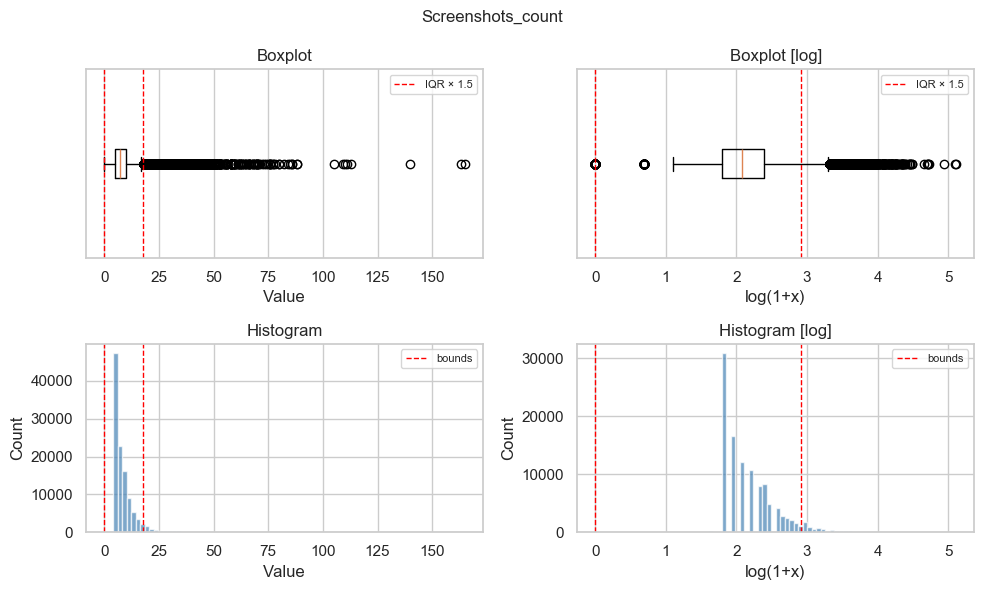

[Screenshots_count]  outliers: 6177 (5.50%)  |  bounds: [0.00, 17.50]  |  min/max: 0.00/165.00  |  skew: 4.18


,N outliers,% outliers,Lower bound,Upper bound,Skewness,Min,Max
Column,,,,,,,
year,1165,1.04,2011.5,2031.50,-1.03,1997.0,2026.00
Required age,1244,1.11,0.0,0.00,9.55,0.0,21.00
Price,7626,6.79,0.0,13.64,22.17,0.0,999.98
Discount,0,0.00,0.0,100.00,1.12,0.0,100.00
DLC count,17205,15.32,0.0,0.00,173.67,0.0,3703.00
Metacritic score,4152,3.70,0.0,0.00,5.05,0.0,97.00
User score,39,0.03,0.0,0.00,57.04,0.0,100.00
Positive,19002,16.92,0.0,105.00,182.91,0.0,7642084.00
Negative,18369,16.36,0.0,30.00,165.04,0.0,1173003.00


In [644]:
df['year'] = pd.to_datetime(df['Release date'], errors='coerce').dt.year

analyze_all(df)

Based on the outlier analysis, I removed rows exceeding the following thresholds: 
- games released before 2010 (too few and probably completely different from todays' games), 
- price above $200, 
- DLC count above 500,
- achievements above 3,500, 
- recommendations above 1,000,000, 
- average and median playtime above 1,000,000 minutes,
- screenshot count above 100. 
These thresholds were chosen manually based on the distributions observed in the plots- values beyond these points are either data errors or extreme outliers that would disproportionately skew the analysis.

For positive and negative review counts, instead of removing the rows, I applied clipping at 2,000,000 and 180,000 respectively- preserving the games in the dataset while limiting the influence of extreme values.

In [645]:
df = df[df['year'] >= 2010]
df = df[df['Price'] <= 200]
df = df[df['DLC count'] <= 500]
df = df[df['Achievements'] <= 3500]
df = df[df['Recommendations'] <= 1e6]
df = df[df['Average playtime forever'] <= 1e6]
df = df[df['Median playtime forever'] <= 1e6]
df = df[df['Screenshots_count'] <= 100]

df['Positive'] = df['Positive'].clip(upper=2e6)
df['Negative'] = df['Negative'].clip(upper=0.18e6)

df.drop(columns=['year'], inplace=True)

## ML model

In [646]:
df

,Release date,Estimated owners,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Median playtime forever,has_support_email,has_support_url,has_website,has_reviews,has_header_image,Screenshots_count,is_top_developer,is_top_publisher,has_multiplayer,has_local_multi,has_workshop,has_achievements,has_controller_support,has_cloud_saves,has_vr,has_accessibility_opts,has_iap,genre_action,genre_rpg,genre_strategy,genre_sim_mgmt,genre_casual_puzzle,genre_rogue,genre_adventure,genre_visual_novel,genre_horror,genre_adult,about_length,name_length,lang_English,lang_French,lang_German,lang_Italian,lang_Spanish,lang_Chinese,lang_Japanese,lang_Korean,lang_Russian,lang_Portuguese,lang_Polish,has_audio_English,has_audio_French,has_audio_German,has_audio_Italian,has_audio_Spanish,has_audio_Chinese,has_audio_Japanese,has_audio_Korean,has_audio_Russian,has_audio_Portuguese,has_audio_Polish,total_lang_count,audio_count,lang_count
496350,2016-07-29,10000.0,0,5.24,65,0,1,0,0,0,0,252,3,0,231,8,8,1,1,1,0,1,10,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1626.0,37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
1034400,2019-05-06,10000.0,0,4.99,0,0,1,1,0,0,0,21,3,0,0,0,0,1,1,1,0,1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1178.0,33,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,4
3292190,2024-10-31,10000.0,0,8.99,0,1,1,0,0,0,0,0,0,19,0,0,0,1,0,0,0,1,7,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1827.0,27,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1
3631080,2025-04-24,10000.0,0,4.99,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,6,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1483.0,13,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1
1654170,2023-04-05,10000.0,0,13.99,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,5,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1834.0,8,1,1,1,1,1,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,9,2,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152910,2026-01-04,1000.0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,5,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,1,0,0,0,518.0,4,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,1
4042800,2026-01-03,1000.0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,8,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,3335.0,30,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,3,2,3
3522550,2026-01-03,1000.0,0,7.99,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,5,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1376.0,15,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1
3680350,2026-01-04,1000.0,0,2.09,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,15,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1032.0,18,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,2,2,2


In [647]:
total = df['Positive'] + df['Negative']
df['positive_ratio'] = df['Positive'] / total

df['is_hit'] = (
    (df['Positive'] >= 1000) & 
    (df['positive_ratio'] >= 0.8)
).astype(int)

print(df['is_hit'].value_counts())
print(f"Hit rate: {df['is_hit'].mean()*100:.1f}%")

is_hit
0    107198
1      4324
Name: count, dtype: int64
Hit rate: 3.9%


In [648]:
df[df['is_hit'] == 1]

,Release date,Estimated owners,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Median playtime forever,has_support_email,has_support_url,has_website,has_reviews,has_header_image,Screenshots_count,is_top_developer,is_top_publisher,has_multiplayer,has_local_multi,has_workshop,has_achievements,has_controller_support,has_cloud_saves,has_vr,has_accessibility_opts,has_iap,genre_action,genre_rpg,genre_strategy,genre_sim_mgmt,genre_casual_puzzle,genre_rogue,genre_adventure,genre_visual_novel,genre_horror,genre_adult,about_length,name_length,lang_English,lang_French,lang_German,lang_Italian,lang_Spanish,lang_Chinese,lang_Japanese,lang_Korean,lang_Russian,lang_Portuguese,lang_Polish,has_audio_English,has_audio_French,has_audio_German,has_audio_Italian,has_audio_Spanish,has_audio_Chinese,has_audio_Japanese,has_audio_Korean,has_audio_Russian,has_audio_Portuguese,has_audio_Polish,total_lang_count,audio_count,lang_count,positive_ratio,is_hit
1025440,2019-09-05,150000.0,0,13.99,0,4,1,0,0,80,0,1025,210,77,994,489,52,1,1,1,1,1,9,0,0,1,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,3578.0,18,1,1,1,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,6,0,6,0.829960,1
688420,2018-11-16,750000.0,0,2.99,80,1,1,1,0,0,0,11367,831,11,11250,342,173,0,1,1,1,1,12,0,0,0,0,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,2038.0,25,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,11,0,11,0.931874,1
1110050,2020-06-11,350000.0,0,1.39,0,1,1,1,0,75,0,1637,230,17,977,205,250,1,1,1,1,1,10,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1137.0,14,1,1,1,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,9,0,9,0.876808,1
715560,2019-02-13,150000.0,0,9.99,0,1,1,0,0,78,0,4608,549,18,4928,320,151,1,1,1,0,1,25,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,718.0,9,1,1,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,5,2,5,0.893543,1
1555110,2021-08-13,150000.0,0,1.59,0,3,1,1,1,0,0,3624,297,30,3902,91,87,1,0,0,0,1,10,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1219.0,37,1,0,1,0,1,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,7,0,7,0.924254,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676820,2017-08-17,350000.0,0,2.99,50,0,1,1,0,83,0,1787,102,13,1481,122,146,1,0,1,1,1,9,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,1853.0,19,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0.946003,1
268650,2020-11-06,350000.0,0,9.99,60,2,1,1,1,0,0,10558,1305,53,10665,5222,523,1,1,1,0,1,24,0,0,1,0,1,1,1,0,0,1,0,1,0,1,1,0,0,1,0,0,0,3391.0,15,1,0,0,0,0,1,1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,4,2,4,0.889994,1
2166060,2023-04-25,350000.0,0,3.59,60,0,1,0,0,0,0,5993,391,19,5667,161,143,1,1,0,0,1,6,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1524.0,21,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,12,2,12,0.938753,1
235900,2013-12-13,350000.0,0,2.49,90,0,1,0,0,0,0,1653,102,0,1123,3864,23,0,1,1,0,1,5,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1365.0,12,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0.941880,1


## Conclusions